# Extension Notebook

In [3]:
import pylidc as pl
import numpy as np
import pandas as pd
import os
import xml.etree.ElementTree as ET
import pandas as pd
from tqdm import tqdm
from skimage.draw import polygon
import SimpleITK as sitk
from radiomics import featureextractor
import ast
import glob

/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [ ]:
import glob
xmls = glob.glob("data/Extension/LIDC-XML-only/tcia-lidc-xml/*/*.xml")
print(f"Found {len(xmls)} XML files")

In [25]:
import os
import xml.etree.ElementTree as ET
import pandas as pd

# Directory containing XMLs
root_dir = "data/Extension/LIDC-XML-only/tcia-lidc-xml/"

# Namespace dictionary
ns = {"lidc": "http://www.nih.gov"}

records = []

# Traverse all folders
for folder in os.listdir(root_dir):
    folder_path = os.path.join(root_dir, folder)
    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):
        if not file.endswith(".xml"):
            continue

        xml_path = os.path.join(folder_path, file)

        try:
            tree = ET.parse(xml_path)
            root = tree.getroot()

            # Each reading session
            for rs in root.findall(".//lidc:readingSession", ns):
                # Each unblinded nodule in the session
                for nodule in rs.findall("lidc:unblindedReadNodule", ns):
                    nodule_id = nodule.find("lidc:noduleID", ns)
                    roi_list = nodule.findall("lidc:roi", ns)
                    num_slices = len(roi_list)
                    if nodule_id is not None:
                        records.append({
                            "File": file,
                            "NoduleID": nodule_id.text,
                            "NumROIs": num_slices
                        })

        except ET.ParseError:
            print(f"Parse error: {xml_path}")

# Convert to DataFrame
df_annotations = pd.DataFrame(records)
print("✅ Total extracted nodules:", len(df_annotations))


✅ Total extracted nodules: 20362


In [24]:
import glob

# Get all XML files in subfolders and root
xml_paths = glob.glob("data/Extension/tcia-lidc-xml/*/*.xml") + \
            glob.glob("data/Extension/tcia-lidc-xml/*.xml")


In [15]:
df_annotations.to_csv("data/ext_annotations.csv", index=False)

In [20]:
import pandas as pd

df = pd.read_csv("data/ext_annotations.csv")

# Check how many unique nodules and patients we have
print("Unique nodules:", df["NoduleID"].nunique())

# Extract patient ID from file path (if needed)
df["PatientID"] = df["File"].apply(lambda x: x.split('/')[-1][:3])  # adjust if needed
print("Unique patients:", df["PatientID"].nunique())



Unique nodules: 11709
Unique patients: 300


In [36]:
import pandas as pd

# Load Excel file
df_diagnosis = pd.read_excel("data/Extension/tcia-diagnosis-data-2012-04-20.xls")

# Clean column names
df_diagnosis.columns = df_diagnosis.columns.str.strip()

# Rename key columns
df_diagnosis.rename(columns={
    "TCIA Patient ID": "PatientID",
    "Diagnosis at the Patient Level\n0=Unknown\n1=benign or non-malignant disease\n2= malignant, primary lung cancer\n3 = malignant metastatic": "Diagnosis"
}, inplace=True)

# Pad Patient ID to match annotation filenames
df_diagnosis["PatientID"] = df_diagnosis["PatientID"].astype(str).str.zfill(3)

# Show result
print(df_diagnosis[["PatientID", "Diagnosis"]].head())


        PatientID  Diagnosis
0  LIDC-IDRI-0068          3
1  LIDC-IDRI-0071          3
2  LIDC-IDRI-0072          2
3  LIDC-IDRI-0088          3
4  LIDC-IDRI-0090          2


In [37]:
df_diagnosis

,PatientID,Diagnosis,Diagnosis Method\n0 = unknown\n1 = review of radiological images to show 2 years of stable nodule\n2 = biopsy\n3 = surgical resection\n4 = progression or response,Primary tumor site for metastatic disease,"Nodule 1\nDiagnosis at the Nodule Level \n0=Unknown\n1=benign or non-malignant disease\n2= malignant, primary lung cancer\n3 = malignant metastatic)",Nodule 1\nDiagnosis Method at the Nodule Level\n0 = unknown\n1 = review of radiological images to show 2 years of stable nodule\n2 = biopsy\n3 = surgical resection\n4 = progression or response,"Nodule 2\nDiagnosis at the Nodule Level \n0=Unknown\n1=benign or non-malignant disease\n2= malignant, primary lung cancer\n3 = malignant metastatic)",Nodule 2\nDiagnosis Method at the Nodule Level\n0 = unknown\n1 = review of radiological images to show 2 years of stable nodule\n2 = biopsy\n3 = surgical resection\n4 = progression or response,"Nodule 3\nDiagnosis at the Nodule Level \n0=Unknown\n1=benign or non-malignant disease\n2= malignant, primary lung cancer\n3 = malignant metastatic)",Nodule 3\nDiagnosis Method at the Nodule Level\n0 = unknown\n1 = review of radiological images to show 2 years of stable nodule\n2 = biopsy\n3 = surgical resection\n4 = progression or response,"Nodule 4\nDiagnosis at the Nodule Level \n0=Unknown\n1=benign or non-malignant disease\n2= malignant, primary lung cancer\n3 = malignant metastatic)",Nodule 4\nDiagnosis Method at the Nodule Level\n0 = unknown\n1 = review of radiological images to show 2 years of stable nodule\n2 = biopsy\n3 = surgical resection\n4 = progression or response,"Nodule 5\nDiagnosis at the Nodule Level \n0=Unknown\n1=benign or non-malignant disease\n2= malignant, primary lung cancer\n3 = malignant metastatic)",Nodule 5\nDiagnosis Method at the Nodule Level\n0 = unknown\n1 = review of radiological images to show 2 years of stable nodule\n2 = biopsy\n3 = surgical resection\n4 = progression or response
0,LIDC-IDRI-0068,3,4,Head & Neck Cancer,3.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,LIDC-IDRI-0071,3,1,Head & Neck,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,LIDC-IDRI-0072,2,4,Lung Cancer,1.0,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,LIDC-IDRI-0088,3,0,Uterine Cancer,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,LIDC-IDRI-0090,2,3,NSCLC,2.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,LIDC-IDRI-0994,2,3,LUL Large cell CA,2.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
153,LIDC-IDRI-1002,2,2,non-small cell carcinoma,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
154,LIDC-IDRI-1004,2,3,LUL NSCLC,2.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
155,LIDC-IDRI-1010,0,0,lymphoma,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
# Extract PatientID from XML file name (first 3 digits)
df_annotations["PatientID"] = df_annotations["File"].str.extract(r"(\d{3})")

# Merge diagnosis info into annotations
df_merged = pd.merge(df_annotations, df_diagnosis[["PatientID", "Diagnosis"]], on="PatientID", how="left")

# Optional: check how many annotations now have valid diagnosis labels
print("Total annotations:", len(df_merged))
print("Annotations with diagnosis:", df_merged["Diagnosis"].notna().sum())

# Save merged dataset if needed
df_merged.to_csv("data/ext_annotations_with_diagnosis.csv", index=False)


Total annotations: 20362
Annotations with diagnosis: 0


In [47]:
# Load diagnosis sheet
df_diagnosis = pd.read_excel("data/Extension/tcia-diagnosis-data-2012-04-20.xls")

# Extract padded PatientID
df_annotations = pd.read_csv("data/ext_annotations.csv")

# Assign it to a short name
df_diagnosis.rename(columns={
    df_diagnosis.columns[0]: "PatientID",
    df_diagnosis.columns[1]: "Diagnosis"
}, inplace=True)


In [48]:
# Extract numeric part from filename and pad to 3 digits
df_annotations["PatientID"] = df_annotations["File"].str.extract(r"(\d{3})")
df_annotations["PatientID"] = "LIDC-IDRI-" + df_annotations["PatientID"].astype(str).str.zfill(4)

# Fix column name in diagnosis file
df_diagnosis.rename(columns={df_diagnosis.columns[0]: "PatientID"}, inplace=True)

# Now try the merge
df_annot_labeled = df_annotations.merge(df_diagnosis[["PatientID", "Diagnosis"]], on="PatientID", how="left")

# Check how many match
print("✅ Labeled annotations:", df_annot_labeled["Diagnosis"].notna().sum())
print("✅ Unique patients with both XML and diagnosis:", df_annot_labeled["PatientID"].nunique())


✅ Labeled annotations: 8229
✅ Unique patients with both XML and diagnosis: 300


In [49]:
df_annot_labeled

,File,NoduleID,NumROIs,PatientID,Diagnosis
0,162.xml,12788,1,LIDC-IDRI-0162,1.0
1,162.xml,12785,1,LIDC-IDRI-0162,1.0
2,162.xml,12777,2,LIDC-IDRI-0162,1.0
3,162.xml,12790,1,LIDC-IDRI-0162,1.0
4,162.xml,12781,2,LIDC-IDRI-0162,1.0
...,...,...,...,...,...
20357,147.xml,0,7,LIDC-IDRI-0147,NaN
20358,147.xml,1,1,LIDC-IDRI-0147,NaN
20359,147.xml,3,1,LIDC-IDRI-0147,NaN
20360,147.xml,4,3,LIDC-IDRI-0147,NaN


In [50]:
# Drop annotations with no diagnosis
df_annot_labeled = df_annot_labeled.dropna(subset=["Diagnosis"]).copy()

# Confirm final counts
print("✅ Final labeled annotations:", len(df_annot_labeled))
print("✅ Final unique patients:", df_annot_labeled['PatientID'].nunique())


✅ Final labeled annotations: 8229
✅ Final unique patients: 120


In [53]:
df_annot_labeled.to_csv("data/ext_annotations_labeled.csv", index=False)

### Filtering to relevant nodules

In [54]:
# Keep nodules with at least 3 ROIs
df_nodules_filtered = df_annot_labeled[df_annot_labeled["NumROIs"] >= 3].copy()

# Confirm results
print("✅ Filtered nodules:", len(df_nodules_filtered))
print("✅ Unique nodules:", df_nodules_filtered['NoduleID'].nunique())
print("✅ Unique patients:", df_nodules_filtered['PatientID'].nunique())


✅ Filtered nodules: 2366
✅ Unique nodules: 1400
✅ Unique patients: 120


### Label Binarization 

In [ ]:
# Convert diagnosis to binary
df_nodules_filtered["Label"] = df_nodules_filtered["Diagnosis"].map(lambda x: 1 if x in [2, 3] else 0)

# Drop any rows with unknown (0 or NaN) if needed
df_final = df_nodules_filtered[df_nodules_filtered["Label"].isin([0, 1])].copy()

print("✅ Final labeled nodules for classification:", len(df_final))

✅ Final labeled nodules for classification: 2366


### Patient 68 - CT SCAN IMAGE FROM DICOM FILE

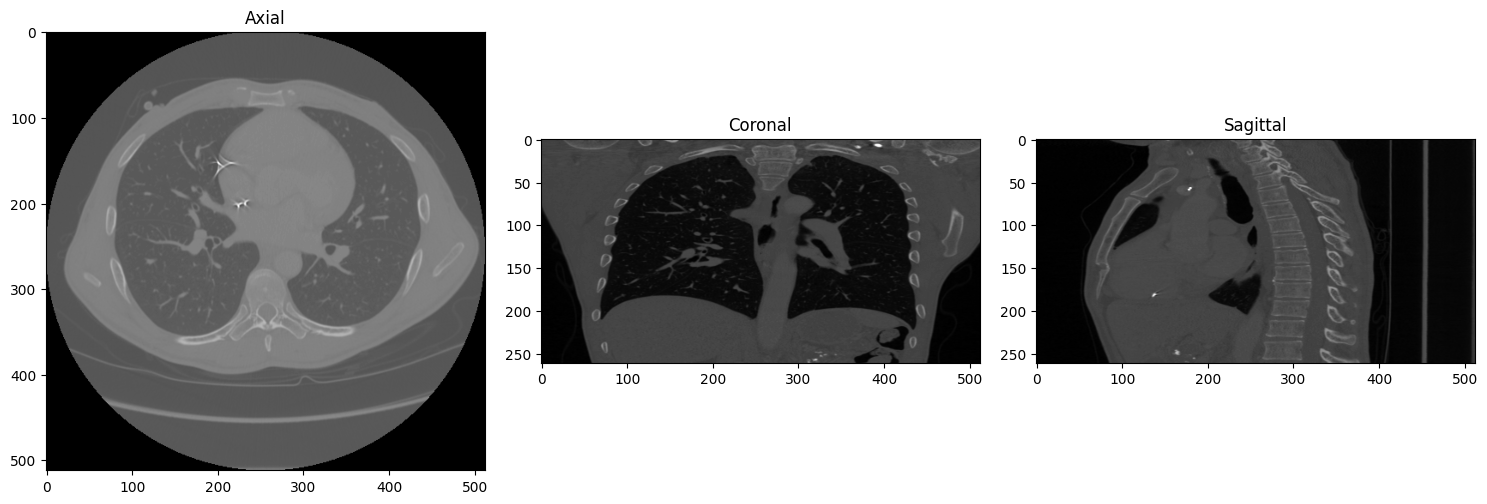

In [68]:
import os
import pydicom
import numpy as np
import matplotlib.pyplot as plt

# Path to a single CT series (change this to another patient/series as needed)
dicom_folder = "data/Extension/DICOM_DATA_120_PATIENTS/manifest-1747667983531/LIDC-IDRI/LIDC-IDRI-0068/01-01-2000-NA-CT CHEST W CONT-80168/4.000000-Recon 3 CT CHEST-26125"

# Load all .dcm slices
slices = []
for fname in os.listdir(dicom_folder):
    if fname.endswith(".dcm"):
        path = os.path.join(dicom_folder, fname)
        slices.append(pydicom.dcmread(path))

# Sort slices by InstanceNumber
slices = sorted(slices, key=lambda x: int(x.InstanceNumber))

# Build 3D numpy volume
volume = np.stack([s.pixel_array for s in slices])
volume = volume.astype(np.int16)

# Show center slices in 3 planes
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(volume[volume.shape[0]//2], cmap="gray")  # Axial
axes[0].set_title("Axial")

axes[1].imshow(volume[:, volume.shape[1]//2, :], cmap="gray")  # Coronal
axes[1].set_title("Coronal")

axes[2].imshow(volume[:, :, volume.shape[2]//2], cmap="gray")  # Sagittal
axes[2].set_title("Sagittal")

plt.tight_layout()
plt.show()


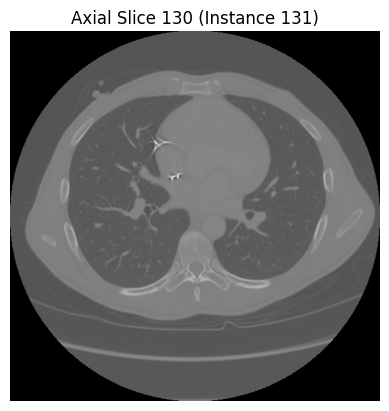

In [70]:
import os
import pydicom
import matplotlib.pyplot as plt

# Define the folder containing the DICOM slices for one scan
dcm_folder = "data/Extension/DICOM_DATA_120_PATIENTS/manifest-1747667983531/LIDC-IDRI/LIDC-IDRI-0068/01-01-2000-NA-CT CHEST W CONT-80168/4.000000-Recon 3 CT CHEST-26125"

# Load all DICOM slices and sort them by InstanceNumber
slices = []
for filename in sorted(os.listdir(dcm_folder)):
    if filename.endswith(".dcm"):
        path = os.path.join(dcm_folder, filename)
        dcm = pydicom.dcmread(path)
        slices.append(dcm)

slices.sort(key=lambda x: int(x.InstanceNumber))

# Extract pixel data from the middle slice
mid_idx = len(slices) // 2
mid_slice = slices[mid_idx]
image = mid_slice.pixel_array

# Display the middle axial slice
plt.imshow(image, cmap="gray")
plt.title(f"Axial Slice {mid_idx} (Instance {mid_slice.InstanceNumber})")
plt.axis("off")
plt.show()


In [143]:
df_final

,File,NoduleID,NumROIs,PatientID,Diagnosis,Label
11,162.xml,2276,3,LIDC-IDRI-0162,1.0,0
13,162.xml,2280,4,LIDC-IDRI-0162,1.0,0
20,163.xml,12760,8,LIDC-IDRI-0163,2.0,1
21,163.xml,16814,8,LIDC-IDRI-0163,2.0,1
22,163.xml,2259,8,LIDC-IDRI-0163,2.0,1
...,...,...,...,...,...,...
20330,231.xml,0,4,LIDC-IDRI-0231,0.0,0
20333,190.xml,Nodule 002,4,LIDC-IDRI-0190,3.0,1
20336,190.xml,IL057_127306,4,LIDC-IDRI-0190,3.0,1
20339,190.xml,MI014_12049,4,LIDC-IDRI-0190,3.0,1


In [72]:
import os
import xml.etree.ElementTree as ET
import pandas as pd

root_dir = "data/Extension/LIDC-XML-only/tcia-lidc-xml/"
ns = {"lidc": "http://www.nih.gov"}

roi_records = []

for folder in os.listdir(root_dir):
    folder_path = os.path.join(root_dir, folder)
    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):
        if not file.endswith(".xml"):
            continue

        xml_path = os.path.join(folder_path, file)
        try:
            tree = ET.parse(xml_path)
            root = tree.getroot()
            patient_id = f"LIDC-IDRI-{file.replace('.xml','').zfill(4)}"

            for rs in root.findall(".//lidc:readingSession", ns):
                for nodule in rs.findall("lidc:unblindedReadNodule", ns):
                    nodule_id = nodule.find("lidc:noduleID", ns)
                    if nodule_id is None:
                        continue
                    nid = nodule_id.text

                    for roi in nodule.findall("lidc:roi", ns):
                        z_pos = float(roi.find("lidc:imageZposition", ns).text)
                        x_coords = []
                        y_coords = []
                        for edge in roi.findall(".//lidc:edgeMap", ns):
                            x = int(edge.find("lidc:xCoord", ns).text)
                            y = int(edge.find("lidc:yCoord", ns).text)
                            x_coords.append(x)
                            y_coords.append(y)

                        if len(x_coords) > 0:
                            roi_records.append({
                                "File": file,
                                "PatientID": patient_id,
                                "NoduleID": nid,
                                "Z": z_pos,
                                "X_coords": x_coords,
                                "Y_coords": y_coords
                            })

        except ET.ParseError:
            print(f"XML parse error in {xml_path}")

df_roi = pd.DataFrame(roi_records)
print("✅ ROI extracted:", len(df_roi))


✅ ROI extracted: 55475


In [74]:
# Make sure NoduleID and File are of the same type
df_roi["NoduleID"] = df_roi["NoduleID"].astype(str)
df_final["NoduleID"] = df_final["NoduleID"].astype(str)

# Filter ROI table to only include nodules in df_final
df_roi_filtered = df_roi.merge(df_final[["File", "NoduleID"]], on=["File", "NoduleID"], how="inner")

print("✅ Filtered ROI records:", len(df_roi_filtered))


✅ Filtered ROI records: 21207


In [153]:
len(df_final['PatientID'].unique())

120

In [114]:
df_final

,File,NoduleID,NumROIs,PatientID,Diagnosis,Label
11,162.xml,2276,3,LIDC-IDRI-0162,1.0,0
13,162.xml,2280,4,LIDC-IDRI-0162,1.0,0
20,163.xml,12760,8,LIDC-IDRI-0163,2.0,1
21,163.xml,16814,8,LIDC-IDRI-0163,2.0,1
22,163.xml,2259,8,LIDC-IDRI-0163,2.0,1
...,...,...,...,...,...,...
20330,231.xml,0,4,LIDC-IDRI-0231,0.0,0
20333,190.xml,Nodule 002,4,LIDC-IDRI-0190,3.0,1
20336,190.xml,IL057_127306,4,LIDC-IDRI-0190,3.0,1
20339,190.xml,MI014_12049,4,LIDC-IDRI-0190,3.0,1


In [144]:
df_roi_filtered

,File,PatientID,NoduleID,Z,X_coords,Y_coords
0,162.xml,LIDC-IDRI-0162,2276,-288.000000,"[98, 99, 100, 100, 100, 100, 100, 100, 100, 99...","[384, 383, 382, 381, 380, 379, 378, 377, 376, ..."
1,162.xml,LIDC-IDRI-0162,2276,-291.000000,"[100, 101, 101, 101, 101, 101, 101, 101, 100, ...","[385, 384, 383, 382, 381, 380, 379, 378, 377, ..."
2,162.xml,LIDC-IDRI-0162,2276,-294.000000,"[95, 96, 97, 98, 99, 99, 99, 99, 98, 98, 97, 9...","[384, 383, 382, 381, 380, 379, 378, 377, 376, ..."
3,162.xml,LIDC-IDRI-0162,2280,-294.000000,"[198, 199, 200, 201, 201, 201, 201, 201, 201, ...","[373, 372, 371, 370, 369, 368, 367, 366, 365, ..."
4,162.xml,LIDC-IDRI-0162,2280,-297.000000,"[199, 200, 201, 202, 203, 204, 205, 205, 205, ...","[376, 375, 374, 374, 373, 373, 372, 371, 370, ..."
...,...,...,...,...,...,...
21202,190.xml,LIDC-IDRI-0190,MI014_12049,-105.830002,"[323, 323, 324, 325, 326, 327, 328, 329, 330, ...","[389, 388, 387, 387, 386, 386, 386, 386, 386, ..."
21203,190.xml,LIDC-IDRI-0190,0,-98.330002,"[325, 324, 323, 322, 321, 320, 319, 318, 317, ...","[374, 375, 375, 376, 377, 378, 379, 379, 379, ..."
21204,190.xml,LIDC-IDRI-0190,0,-100.830002,"[326, 325, 324, 323, 322, 322, 321, 321, 320, ...","[372, 373, 373, 373, 373, 374, 375, 376, 377, ..."
21205,190.xml,LIDC-IDRI-0190,0,-103.330002,"[325, 324, 323, 322, 321, 320, 319, 318, 317, ...","[377, 378, 378, 378, 379, 379, 380, 381, 382, ..."


In [188]:
df_roi_filtered.to_csv("data/roi_filtered.csv", index=False)

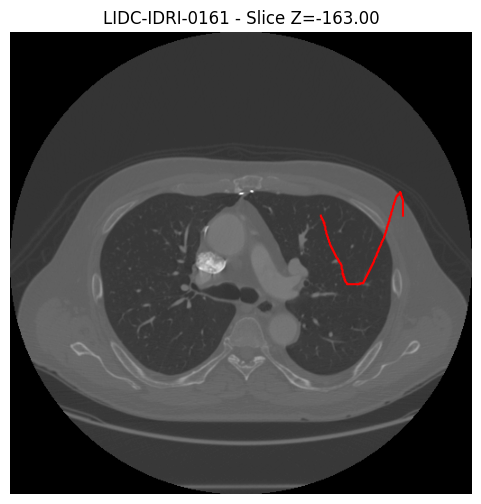

In [117]:
import matplotlib.pyplot as plt
import pydicom
import numpy as np
import os

row = df_roi_filtered.iloc[55]

z_val = row["Z"]
x_coords = row["X_coords"]
y_coords = row["Y_coords"]
file = row["File"]
patient_id = row["PatientID"]

dicom_root = "data/Extension/DICOM_DATA_120_PATIENTS/manifest-1747667983531/LIDC-IDRI/"
dicom_patient_dir = os.path.join(dicom_root, patient_id)

dicom_files = []
for root, _, files in os.walk(dicom_patient_dir):
    for f in files:
        if f.endswith(".dcm"):
            dicom_files.append(os.path.join(root, f))

# Build a list of (z, dicom) from ImagePositionPatient instead of SliceLocation
slices = []
for f in dicom_files:
    dcm = pydicom.dcmread(f)
    if hasattr(dcm, "ImagePositionPatient"):
        z_pos = float(dcm.ImagePositionPatient[2])
        slices.append((z_pos, dcm))

# Sort and match on true image-space z
slices.sort(key=lambda x: x[0])
locations = [s[0] for s in slices]

z_val = float(row["Z"])  # Z from df_roi_filtered
closest_idx = np.argmin(np.abs(np.array(locations) - z_val))
dcm_slice = slices[closest_idx][1]


# Plot
plt.figure(figsize=(6, 6))
plt.imshow(dcm_slice.pixel_array, cmap="gray")
plt.plot(x_coords, y_coords, color="red", linewidth=1.5)
plt.title(f"{patient_id} - Slice Z={z_val:.2f}")
plt.axis("off")
plt.show()


In [108]:
print(f"Pixel Spacing: {dcm_slice.PixelSpacing}")
print(f"Image Position (Z): {dcm_slice.ImagePositionPatient[2]}")
print(f"Z in df_roi_filtered: {z_val}")


Pixel Spacing: [0.820312, 0.820312]
Image Position (Z): -163.000000
Z in df_roi_filtered: -163.0


In [110]:
print(type(x_coords.iloc[0]), x_coords.iloc[0])


AttributeError: 'list' object has no attribute 'iloc'

In [111]:
print("X: type =", type(x_coords), "min =", min(x_coords), "max =", max(x_coords), "len =", len(x_coords))
print("Y: type =", type(y_coords), "min =", min(y_coords), "max =", max(y_coords), "len =", len(y_coords))


X: type = <class 'list'> min = 344 max = 435 len = 272
Y: type = <class 'list'> min = 177 max = 279 len = 272


In [112]:
print("DICOM shape:", dcm_slice.pixel_array.shape)


DICOM shape: (512, 512)


Z: -661.400024
X: min=165, max=173, len=20
Y: min=243, max=251, len=20
DICOM shape: (512, 512)


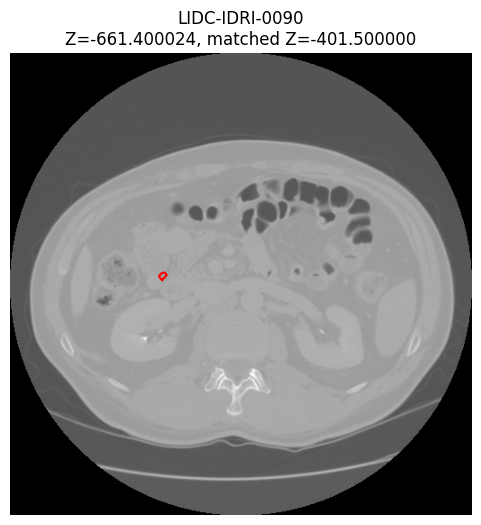

In [125]:
import os
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import pydicom

# One XML path for manual debugging
xml_path = "data/Extension/LIDC-XML-only/tcia-lidc-xml/189/090.xml"
ns = {"lidc": "http://www.nih.gov"}

# Read XML
tree = ET.parse(xml_path)
root = tree.getroot()

# Just get the first reading session and first ROI
session = root.find(".//lidc:readingSession", ns)
nodule = session.find(".//lidc:unblindedReadNodule", ns)
roi = nodule.find("lidc:roi", ns)

# Z slice and pixel coordinates
z = float(roi.find("lidc:imageZposition", ns).text)
x_coords = [int(em.find("lidc:xCoord", ns).text) for em in roi.findall("lidc:edgeMap", ns)]
y_coords = [int(em.find("lidc:yCoord", ns).text) for em in roi.findall("lidc:edgeMap", ns)]

print(f"Z: {z}")
print(f"X: min={min(x_coords)}, max={max(x_coords)}, len={len(x_coords)}")
print(f"Y: min={min(y_coords)}, max={max(y_coords)}, len={len(y_coords)}")

# Now load all DICOM slices for patient LIDC-IDRI-0090
dcm_dir = "data/Extension/DICOM_DATA_120_PATIENTS/manifest-1747667983531/LIDC-IDRI/LIDC-IDRI-0090"
dcm_files = [os.path.join(dp, f) for dp, _, filenames in os.walk(dcm_dir) for f in filenames if f.endswith(".dcm")]

# Find best match by SliceLocation
slices = []
for f in dcm_files:
    dcm = pydicom.dcmread(f)
    if hasattr(dcm, "SliceLocation"):
        slices.append((abs(dcm.SliceLocation - z), dcm))

if not slices:
    raise ValueError("No matching DICOM slice found.")

closest_dcm = sorted(slices, key=lambda x: x[0])[0][1]

print(f"DICOM shape: {closest_dcm.pixel_array.shape}")

# Plot overlay
plt.figure(figsize=(6,6))
plt.imshow(closest_dcm.pixel_array, cmap="gray")
plt.plot(x_coords, y_coords, 'r-', linewidth=1.5)
plt.title(f"LIDC-IDRI-0090\nZ={z}, matched Z={closest_dcm.SliceLocation}")
plt.axis("off")
plt.show()


In [142]:
import os
import pydicom
import matplotlib.pyplot as plt
import numpy as np

# --- Select a row from df_roi_filtered ---
row = df_roi_filtered.iloc[0]  # Change index as needed
patient_id = row["PatientID"]
file = row["File"]
nodule_id = row["NoduleID"]
z = row["Z"]
x_coords = row["X_coords"]
y_coords = row["Y_coords"]

# --- Re-parse the XML to get the SOPInstanceUID ---
import xml.etree.ElementTree as ET

ns = {"lidc": "http://www.nih.gov"}
# Updated XML path resolution (based on known folders)
available_folders = ['157', '185', '186', '187', '188','189']
found = False
for folder in available_folders:
    xml_candidate_path = os.path.join("data/Extension/LIDC-XML-only/tcia-lidc-xml", folder, file)
    if os.path.exists(xml_candidate_path):
        xml_path = xml_candidate_path
        found = True
        break

if not found:
    raise FileNotFoundError(f"❌ XML file {file} not found in available folders.")

# Parse the XML and extract SOP UID
tree = ET.parse(xml_path)
root = tree.getroot()


# Find the matching nodule and ROI with same Z
sop_uid_from_xml = None
for read in root.findall(".//lidc:readingSession", ns):
    for nodule in read.findall("lidc:unblindedReadNodule", ns):
        nid = nodule.find("lidc:noduleID", ns)
        if nid is not None and nid.text == str(nodule_id):
            for roi in nodule.findall("lidc:roi", ns):
                z_xml = roi.find("lidc:imageZposition", ns)
                if z_xml is not None and float(z_xml.text) == float(z):
                    sop_uid_node = roi.find("lidc:imageSOP_UID", ns)
                    if sop_uid_node is not None:
                        sop_uid_from_xml = sop_uid_node.text
                        break

print("✅ SOP UID from XML:", sop_uid_from_xml)

# --- Load all DICOMs for this patient ---
dicom_root = "data/Extension/DICOM_DATA_120_PATIENTS/manifest-1747667983531/LIDC-IDRI"
dicom_patient_dir = os.path.join(dicom_root, patient_id)
dicom_files = []
for root_dir, _, files in os.walk(dicom_patient_dir):
    for f in files:
        if f.endswith(".dcm"):
            dicom_files.append(os.path.join(root_dir, f))

# --- Match DICOM with the exact SOP UID ---
matched_dcm = None
for f in dicom_files:
    dcm = pydicom.dcmread(f)
    if hasattr(dcm, "SOPInstanceUID") and dcm.SOPInstanceUID == sop_uid_from_xml:
        matched_dcm = dcm
        break

if matched_dcm is None:
    raise ValueError("❌ No matching DICOM slice found for SOP UID.")

# --- Plot with overlay ---
plt.figure(figsize=(6, 6))
plt.imshow(matched_dcm.pixel_array, cmap="gray")
plt.plot(x_coords, y_coords, color="red", linewidth=1.5)
plt.title(f"{patient_id}\nZ={z:.2f}, matched SOP UID={matched_dcm.SOPInstanceUID}")
plt.axis("off")
plt.show()


✅ SOP UID from XML: 1.3.6.1.4.1.14519.5.2.1.6279.6001.323951464939326206462330962054


ValueError: ❌ No matching DICOM slice found for SOP UID.

In [140]:
print("From XML:", sop_uid_from_xml)

lst=[]
for f in dicom_files:
    dcm = pydicom.dcmread(f, stop_before_pixels=True)
    print(dcm.SOPInstanceUID)
    lst.append(dcm.SOPInstanceUID)


# --- Check if the SOPInstanceUID is in the DICOM ---

sop_uid_from_xml in lst


From XML: 1.3.6.1.4.1.14519.5.2.1.6279.6001.110317331891752951780442767822
1.2.276.0.7230010.3.1.4.0.11503.1553294538.614963
1.2.276.0.7230010.3.1.4.0.11570.1553294556.500606
1.2.276.0.7230010.3.1.4.0.11500.1553294532.952937
1.2.276.0.7230010.3.1.4.0.11506.1553294547.525912
1.2.276.0.7230010.3.1.4.0.11602.1553294563.78336
1.2.276.0.7230010.3.1.4.0.11603.1553294566.313655
1.2.276.0.7230010.3.1.4.0.11643.1553294575.465898
1.2.276.0.7230010.3.1.4.0.11646.1553294584.410203
1.2.276.0.7230010.3.1.4.0.11534.1553294553.425988
1.2.276.0.7230010.3.1.4.0.11507.1553294550.424004
1.2.276.0.7230010.3.1.4.0.11505.1553294544.468270
1.2.276.0.7230010.3.1.4.0.11642.1553294572.508860
1.2.276.0.7230010.3.1.4.0.11647.1553294587.292373
1.2.276.0.7230010.3.1.4.0.11644.1553294578.304791
1.2.276.0.7230010.3.1.4.0.11501.1553294535.778170
1.2.276.0.7230010.3.1.4.0.11645.1553294581.345830
1.2.276.0.7230010.3.1.4.0.11596.1553294559.658420
1.3.6.1.4.1.14519.5.2.1.6279.6001.167692469052434580802970576171
1.3.6.1.4.1

False

In [141]:


lst


['1.2.276.0.7230010.3.1.4.0.11503.1553294538.614963',
 '1.2.276.0.7230010.3.1.4.0.11570.1553294556.500606',
 '1.2.276.0.7230010.3.1.4.0.11500.1553294532.952937',
 '1.2.276.0.7230010.3.1.4.0.11506.1553294547.525912',
 '1.2.276.0.7230010.3.1.4.0.11602.1553294563.78336',
 '1.2.276.0.7230010.3.1.4.0.11603.1553294566.313655',
 '1.2.276.0.7230010.3.1.4.0.11643.1553294575.465898',
 '1.2.276.0.7230010.3.1.4.0.11646.1553294584.410203',
 '1.2.276.0.7230010.3.1.4.0.11534.1553294553.425988',
 '1.2.276.0.7230010.3.1.4.0.11507.1553294550.424004',
 '1.2.276.0.7230010.3.1.4.0.11505.1553294544.468270',
 '1.2.276.0.7230010.3.1.4.0.11642.1553294572.508860',
 '1.2.276.0.7230010.3.1.4.0.11647.1553294587.292373',
 '1.2.276.0.7230010.3.1.4.0.11644.1553294578.304791',
 '1.2.276.0.7230010.3.1.4.0.11501.1553294535.778170',
 '1.2.276.0.7230010.3.1.4.0.11645.1553294581.345830',
 '1.2.276.0.7230010.3.1.4.0.11596.1553294559.658420',
 '1.3.6.1.4.1.14519.5.2.1.6279.6001.167692469052434580802970576171',
 '1.3.6.1.4.1.

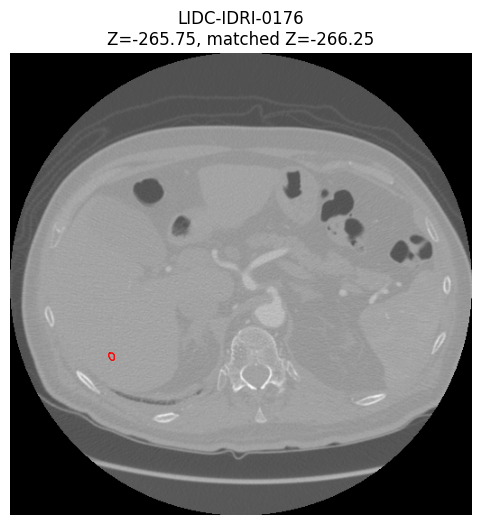

In [183]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pydicom

# ---- Inputs ----
# Row from df_final (e.g. row 1)
row_final = df_final.iloc[50]
pid = row_final["PatientID"]
nid = row_final["NoduleID"]

# Filter ROI DataFrame
roi_matches = df_roi_filtered[(df_roi_filtered["PatientID"] == pid) & (df_roi_filtered["NoduleID"] == nid)]

if roi_matches.empty:
    raise ValueError("❌ No ROI match found in df_roi_filtered.")

# Pick one of the ROIs — here we pick the middle Z
roi_row = roi_matches.iloc[len(roi_matches)//2]
z = roi_row["Z"]
x_coords = roi_row["X_coords"]
y_coords = roi_row["Y_coords"]

# ---- Load DICOM files for this patient ----
dicom_root = "data/Extension/DICOM_DATA_120_PATIENTS/manifest-1747667983531/LIDC-IDRI"
dicom_patient_dir = os.path.join(dicom_root, pid)

dicom_files = []
for root, dirs, files in os.walk(dicom_patient_dir):
    for f in files:
        if f.endswith(".dcm"):
            dicom_files.append(os.path.join(root, f))

# Load all slices and sort by Z (SliceLocation)
slices = []
for f in dicom_files:
    dcm = pydicom.dcmread(f)
    if hasattr(dcm, "SliceLocation"):
        slices.append((abs(dcm.SliceLocation - z), dcm))

if not slices:
    raise ValueError("❌ No matching DICOM slice found.")

# Closest slice
closest_dcm = sorted(slices, key=lambda x: x[0])[0][1]

# ---- Plot ----
plt.figure(figsize=(6,6))
plt.imshow(closest_dcm.pixel_array, cmap="gray")
plt.plot(x_coords, y_coords, color="red", linewidth=1)
plt.title(f"{pid}\nZ={z:.2f}, matched Z={closest_dcm.SliceLocation:.2f}")
plt.axis("off")
plt.show()


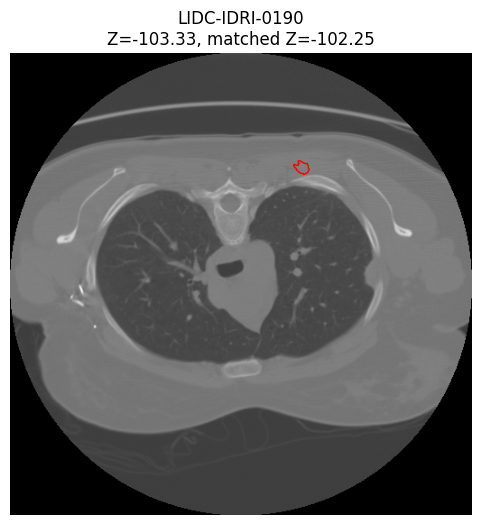

In [178]:
plt.figure(figsize=(6,6))
plt.imshow(closest_dcm.pixel_array, cmap="gray", origin="lower")  # or try "lower"
plt.plot(x_coords, y_coords, color="red", linewidth=1)
plt.title(f"{pid}\nZ={z:.2f}, matched Z={closest_dcm.SliceLocation:.2f}")
plt.axis("off")
plt.show()



In [185]:
import pydicom

# Step 1: For a failing PatientID + NoduleID
row = df_roi_filtered.iloc[55]  # or another failed row
pid = row["PatientID"]
z = row["Z"]

# Step 2: Traverse DICOMs and check for SliceLocation/ImagePositionPatient
dicom_dir = os.path.join("data/Extension/DICOM_DATA_120_PATIENTS/...", pid)

slice_locations = []
image_positions = []
uids = []

for root, dirs, files in os.walk(dicom_dir):
    for f in files:
        if f.endswith(".dcm"):
            dcm = pydicom.dcmread(os.path.join(root, f), stop_before_pixels=True)
            if hasattr(dcm, "SliceLocation"):
                slice_locations.append(dcm.SliceLocation)
            if hasattr(dcm, "ImagePositionPatient"):
                image_positions.append(dcm.ImagePositionPatient[2])
            if hasattr(dcm, "SOPInstanceUID"):
                uids.append(dcm.SOPInstanceUID)

print(f"SliceLocations: {min(slice_locations):.2f} to {max(slice_locations):.2f}")
print(f"ImagePositionsZ: {min(image_positions):.2f} to {max(image_positions):.2f}")
print(f"Z from XML: {z:.2f}")


ValueError: min() arg is an empty sequence

In [189]:
import os
import pydicom

# Path to your DICOM data
dicom_root = "data/Extension/DICOM_DATA_120_PATIENTS/manifest-1747667983531/LIDC-IDRI"

# Gather all available (PatientID, Z) pairs from DICOM
available_z = set()

for patient_id in os.listdir(dicom_root):
    patient_path = os.path.join(dicom_root, patient_id)
    for root, dirs, files in os.walk(patient_path):
        for file in files:
            if file.endswith(".dcm"):
                fpath = os.path.join(root, file)
                try:
                    dcm = pydicom.dcmread(fpath)
                    if hasattr(dcm, "SliceLocation"):
                        available_z.add((patient_id, round(float(dcm.SliceLocation), 1)))
                except Exception as e:
                    continue

# Compare with df_roi_filtered
df_roi_filtered["Z_rounded"] = df_roi_filtered["Z"].round(1)
df_roi_filtered["has_match"] = df_roi_filtered.apply(
    lambda row: (row["PatientID"], row["Z_rounded"]) in available_z, axis=1
)

missing_df = df_roi_filtered[~df_roi_filtered["has_match"]]

print("🔍 Missing slice matches:", len(missing_df))
print(missing_df[["PatientID", "Z", "Z_rounded"]].drop_duplicates().head(10))


🔍 Missing slice matches: 19693
         PatientID       Z  Z_rounded
0   LIDC-IDRI-0162  -288.0     -288.0
1   LIDC-IDRI-0162  -291.0     -291.0
2   LIDC-IDRI-0162  -294.0     -294.0
4   LIDC-IDRI-0162  -297.0     -297.0
5   LIDC-IDRI-0162  -300.0     -300.0
6   LIDC-IDRI-0162  -303.0     -303.0
10  LIDC-IDRI-0163  1584.0     1584.0
11  LIDC-IDRI-0163  1581.0     1581.0
12  LIDC-IDRI-0163  1578.0     1578.0
13  LIDC-IDRI-0163  1575.0     1575.0


In [190]:
missing_df

,File,PatientID,NoduleID,Z,X_coords,Y_coords,Z_rounded,has_match
0,162.xml,LIDC-IDRI-0162,2276,-288.000000,"[98, 99, 100, 100, 100, 100, 100, 100, 100, 99...","[384, 383, 382, 381, 380, 379, 378, 377, 376, ...",-288.0,False
1,162.xml,LIDC-IDRI-0162,2276,-291.000000,"[100, 101, 101, 101, 101, 101, 101, 101, 100, ...","[385, 384, 383, 382, 381, 380, 379, 378, 377, ...",-291.0,False
2,162.xml,LIDC-IDRI-0162,2276,-294.000000,"[95, 96, 97, 98, 99, 99, 99, 99, 98, 98, 97, 9...","[384, 383, 382, 381, 380, 379, 378, 377, 376, ...",-294.0,False
3,162.xml,LIDC-IDRI-0162,2280,-294.000000,"[198, 199, 200, 201, 201, 201, 201, 201, 201, ...","[373, 372, 371, 370, 369, 368, 367, 366, 365, ...",-294.0,False
4,162.xml,LIDC-IDRI-0162,2280,-297.000000,"[199, 200, 201, 202, 203, 204, 205, 205, 205, ...","[376, 375, 374, 374, 373, 373, 372, 371, 370, ...",-297.0,False
...,...,...,...,...,...,...,...,...
21202,190.xml,LIDC-IDRI-0190,MI014_12049,-105.830002,"[323, 323, 324, 325, 326, 327, 328, 329, 330, ...","[389, 388, 387, 387, 386, 386, 386, 386, 386, ...",-105.8,False
21203,190.xml,LIDC-IDRI-0190,0,-98.330002,"[325, 324, 323, 322, 321, 320, 319, 318, 317, ...","[374, 375, 375, 376, 377, 378, 379, 379, 379, ...",-98.3,False
21204,190.xml,LIDC-IDRI-0190,0,-100.830002,"[326, 325, 324, 323, 322, 322, 321, 321, 320, ...","[372, 373, 373, 373, 373, 374, 375, 376, 377, ...",-100.8,False
21205,190.xml,LIDC-IDRI-0190,0,-103.330002,"[325, 324, 323, 322, 321, 320, 319, 318, 317, ...","[377, 378, 378, 378, 379, 379, 380, 381, 382, ...",-103.3,False


In [191]:
# Build SOP UID to DICOM path map
sop_uid_map = {}

for root, dirs, files in os.walk(dicom_root):
    for f in files:
        if f.endswith(".dcm"):
            fpath = os.path.join(root, f)
            try:
                dcm = pydicom.dcmread(fpath, stop_before_pixels=True)
                sop_uid = dcm.SOPInstanceUID
                sop_uid_map[sop_uid] = fpath
            except:
                continue


In [192]:
sop_uid = roi.find("lidc:imageSOP_UID", ns)
sop_uid_val = sop_uid.text if sop_uid is not None else None

records.append({
    "File": file,
    "PatientID": patient_id,
    "NoduleID": nodule_id,
    "Z": z_val,
    "X_coords": x_coords,
    "Y_coords": y_coords,
    "SOPInstanceUID": sop_uid_val,
})


In [193]:
sop_uid = df_roi_filtered.iloc[55]["SOPInstanceUID"]

if sop_uid not in sop_uid_map:
    raise ValueError("❌ No matching DICOM found for SOP UID.")

dcm_path = sop_uid_map[sop_uid]
dcm = pydicom.dcmread(dcm_path)


KeyError: 'SOPInstanceUID'

In [ ]:
plt.figure(figsize=(6, 6))
plt.imshow(dcm.pixel_array, cmap="gray")
plt.plot(x_coords, y_coords, color="red", linewidth=1)
plt.title(f"{pid}\nSOP UID match found")
plt.axis("off")
plt.show()


In [194]:
import os
import xml.etree.ElementTree as ET
import pandas as pd

# XML folder path
xml_root = "data/Extension/LIDC-XML-only/tcia-lidc-xml/"

# Namespaces
ns = {"lidc": "http://www.nih.gov"}

records = []

# Traverse folders and XML files
for folder in os.listdir(xml_root):
    folder_path = os.path.join(xml_root, folder)
    if not os.path.isdir(folder_path):
        continue

    for file in os.listdir(folder_path):
        if not file.endswith(".xml"):
            continue

        xml_path = os.path.join(folder_path, file)
        try:
            tree = ET.parse(xml_path)
            root = tree.getroot()
            patient_id = file.split(".")[0]  # e.g., 162 from 162.xml
            patient_id = f"LIDC-IDRI-{int(patient_id):04d}"

            for reading_session in root.findall(".//lidc:readingSession", ns):
                for nodule in reading_session.findall("lidc:unblindedReadNodule", ns):
                    nodule_id = nodule.find("lidc:noduleID", ns)
                    if nodule_id is None:
                        continue
                    nodule_id = nodule_id.text

                    for roi in nodule.findall("lidc:roi", ns):
                        z = roi.find("lidc:imageZposition", ns)
                        sop = roi.find("lidc:imageSOP_UID", ns)
                        edge_maps = roi.findall("lidc:edgeMap", ns)

                        if z is None or sop is None or len(edge_maps) == 0:
                            continue

                        z_val = float(z.text)
                        sop_uid = sop.text

                        x_coords = [int(em.find("lidc:xCoord", ns).text) for em in edge_maps]
                        y_coords = [int(em.find("lidc:yCoord", ns).text) for em in edge_maps]

                        records.append({
                            "File": file,
                            "PatientID": patient_id,
                            "NoduleID": nodule_id,
                            "Z": z_val,
                            "X_coords": x_coords,
                            "Y_coords": y_coords,
                            "SOPInstanceUID": sop_uid
                        })

        except ET.ParseError:
            print(f"❌ Parse error: {xml_path}")
        except Exception as e:
            print(f"⚠️ Error in {xml_path}: {e}")

# Create DataFrame
df_roi_filtered = pd.DataFrame(records)
print(f"✅ Total ROI entries extracted: {len(df_roi_filtered)}")

# Save (optional)
df_roi_filtered.to_csv("data/roi_filtered_with_sop.csv", index=False)


✅ Total ROI entries extracted: 55475


In [195]:
df_roi_filtered

,File,PatientID,NoduleID,Z,X_coords,Y_coords,SOPInstanceUID
0,162.xml,LIDC-IDRI-0162,12788,-207.00,[190],[396],1.3.6.1.4.1.14519.5.2.1.6279.6001.226013134192...
1,162.xml,LIDC-IDRI-0162,12785,-219.00,[154],[194],1.3.6.1.4.1.14519.5.2.1.6279.6001.194025269042...
2,162.xml,LIDC-IDRI-0162,12777,-288.00,"[97, 98, 99, 99, 99, 98, 98, 98, 97, 97, 96, 9...","[383, 382, 381, 380, 379, 378, 377, 376, 375, ...",1.3.6.1.4.1.14519.5.2.1.6279.6001.323951464939...
3,162.xml,LIDC-IDRI-0162,12777,-291.00,"[97, 98, 99, 99, 99, 99, 98, 98, 97, 97, 96, 9...","[383, 382, 382, 381, 380, 379, 378, 377, 376, ...",1.3.6.1.4.1.14519.5.2.1.6279.6001.290031872380...
4,162.xml,LIDC-IDRI-0162,12790,-294.00,[459],[268],1.3.6.1.4.1.14519.5.2.1.6279.6001.339058544234...
...,...,...,...,...,...,...,...
55470,147.xml,LIDC-IDRI-0147,3,-92.75,[190],[402],1.3.6.1.4.1.14519.5.2.1.6279.6001.366185049620...
55471,147.xml,LIDC-IDRI-0147,4,-62.75,"[311, 312, 312, 313, 314, 315, 316, 316, 316, ...","[382, 381, 380, 380, 381, 381, 382, 383, 384, ...",1.3.6.1.4.1.14519.5.2.1.6279.6001.782874840434...
55472,147.xml,LIDC-IDRI-0147,4,-65.25,"[310, 310, 310, 311, 312, 313, 314, 315, 316, ...","[383, 382, 381, 380, 379, 379, 380, 380, 381, ...",1.3.6.1.4.1.14519.5.2.1.6279.6001.219029389803...
55473,147.xml,LIDC-IDRI-0147,4,-67.75,"[310, 311, 311, 312, 313, 314, 315, 315, 315, ...","[382, 381, 380, 380, 380, 380, 381, 382, 383, ...",1.3.6.1.4.1.14519.5.2.1.6279.6001.555114462353...


In [196]:
# Ensure both columns are strings for safe merge
df_final["PatientID"] = df_final["PatientID"].astype(str)
df_final["NoduleID"] = df_final["NoduleID"].astype(str)
df_roi_filtered["PatientID"] = df_roi_filtered["PatientID"].astype(str)
df_roi_filtered["NoduleID"] = df_roi_filtered["NoduleID"].astype(str)

# Merge to filter only those ROI entries present in df_final
df_roi_matched = df_roi_filtered.merge(
    df_final[["PatientID", "NoduleID"]].drop_duplicates(),
    on=["PatientID", "NoduleID"],
    how="inner"
)

print("✅ Filtered ROI shape:", df_roi_matched.shape)


✅ Filtered ROI shape: (17358, 7)


In [204]:
df_roi_matched

,File,PatientID,NoduleID,Z,X_coords,Y_coords,SOPInstanceUID
0,162.xml,LIDC-IDRI-0162,2276,-288.000000,"[98, 99, 100, 100, 100, 100, 100, 100, 100, 99...","[384, 383, 382, 381, 380, 379, 378, 377, 376, ...",1.3.6.1.4.1.14519.5.2.1.6279.6001.323951464939...
1,162.xml,LIDC-IDRI-0162,2276,-291.000000,"[100, 101, 101, 101, 101, 101, 101, 101, 100, ...","[385, 384, 383, 382, 381, 380, 379, 378, 377, ...",1.3.6.1.4.1.14519.5.2.1.6279.6001.290031872380...
2,162.xml,LIDC-IDRI-0162,2276,-294.000000,"[95, 96, 97, 98, 99, 99, 99, 99, 98, 98, 97, 9...","[384, 383, 382, 381, 380, 379, 378, 377, 376, ...",1.3.6.1.4.1.14519.5.2.1.6279.6001.339058544234...
3,162.xml,LIDC-IDRI-0162,2280,-294.000000,"[198, 199, 200, 201, 201, 201, 201, 201, 201, ...","[373, 372, 371, 370, 369, 368, 367, 366, 365, ...",1.3.6.1.4.1.14519.5.2.1.6279.6001.339058544234...
4,162.xml,LIDC-IDRI-0162,2280,-297.000000,"[199, 200, 201, 202, 203, 204, 205, 205, 205, ...","[376, 375, 374, 374, 373, 373, 372, 371, 370, ...",1.3.6.1.4.1.14519.5.2.1.6279.6001.358590247754...
...,...,...,...,...,...,...,...
17353,190.xml,LIDC-IDRI-0190,MI014_12049,-105.830002,"[323, 323, 324, 325, 326, 327, 328, 329, 330, ...","[389, 388, 387, 387, 386, 386, 386, 386, 386, ...",1.3.6.1.4.1.14519.5.2.1.6279.6001.899026751566...
17354,190.xml,LIDC-IDRI-0190,0,-98.330002,"[325, 324, 323, 322, 321, 320, 319, 318, 317, ...","[374, 375, 375, 376, 377, 378, 379, 379, 379, ...",1.3.6.1.4.1.14519.5.2.1.6279.6001.276510521741...
17355,190.xml,LIDC-IDRI-0190,0,-100.830002,"[326, 325, 324, 323, 322, 322, 321, 321, 320, ...","[372, 373, 373, 373, 373, 374, 375, 376, 377, ...",1.3.6.1.4.1.14519.5.2.1.6279.6001.933752059918...
17356,190.xml,LIDC-IDRI-0190,0,-103.330002,"[325, 324, 323, 322, 321, 320, 319, 318, 317, ...","[377, 378, 378, 378, 379, 379, 380, 381, 382, ...",1.3.6.1.4.1.14519.5.2.1.6279.6001.298260318614...


In [206]:
import matplotlib.pyplot as plt
import pydicom
import os

# --- Choose a row to plot ---
row = df_roi_matched.iloc[0]  # change the index as needed

pid = row["PatientID"]
sop_uid = row["SOPInstanceUID"]
x_coords = row["X_coords"]
y_coords = row["Y_coords"]

# --- Load all DICOMs for this patient ---
dicom_root = "data/Extension/DICOM_DATA_120_PATIENTS/manifest-1747667983531/LIDC-IDRI"
dicom_patient_dir = os.path.join(dicom_root, pid)

dicom_files = []
for root, _, files in os.walk(dicom_patient_dir):
    for f in files:
        if f.endswith(".dcm"):
            dicom_files.append(os.path.join(root, f))

# Create SOP -> DICOM file map
sop_uid_map = {}
for path in dicom_files:
    dcm = pydicom.dcmread(path, stop_before_pixels=True)
    if hasattr(dcm, "SOPInstanceUID"):
        sop_uid_map[dcm.SOPInstanceUID] = path

# --- Load matching slice ---
if sop_uid not in sop_uid_map:
    raise ValueError("❌ Matching SOP UID not found in DICOM files.")

dcm_path = sop_uid_map[sop_uid]
dcm = pydicom.dcmread(dcm_path)

# --- Plot image + ROI ---
plt.figure(figsize=(6, 6))
plt.imshow(dcm.pixel_array, cmap="gray")
plt.plot(x_coords, y_coords, color="red", linewidth=1)
plt.title(f"{pid}\nSOP UID = {sop_uid}")
plt.axis("off")
plt.show()


ValueError: ❌ Matching SOP UID not found in DICOM files.

In [207]:
print(f"🧬 SOP UID from ROI: {sop_uid}")
print(f"📁 Scanning DICOM directory: {dicom_patient_dir}")
print(f"📄 Total DICOM files found: {len(dicom_files)}")
print(f"🔍 First few SOP UIDs in map: {list(sop_uid_map.keys())[:5]}")


🧬 SOP UID from ROI: 1.3.6.1.4.1.14519.5.2.1.6279.6001.323951464939326206462330962054
📁 Scanning DICOM directory: data/Extension/DICOM_DATA_120_PATIENTS/manifest-1747667983531/LIDC-IDRI/LIDC-IDRI-0162
📄 Total DICOM files found: 145
🔍 First few SOP UIDs in map: ['1.3.6.1.4.1.14519.5.2.1.6279.6001.393998320247099074798413764549', '1.3.6.1.4.1.14519.5.2.1.6279.6001.274667677833004828688049894674', '1.3.6.1.4.1.14519.5.2.1.6279.6001.238542920322796146404598165260', '1.3.6.1.4.1.14519.5.2.1.6279.6001.114644591638367521317564614660', '1.3.6.1.4.1.14519.5.2.1.6279.6001.152485514925201599124035368216']


In [2]:
import os
import xml.etree.ElementTree as ET
import pandas as pd

# --- Setup ---
base_dir = "data/Extension/DICOM_DATA_120_PATIENTS/manifest-1747667983531/LIDC-IDRI"
ns = {"lidc": "http://www.nih.gov"}
roi_records = []

all_patients = sorted(os.listdir(base_dir))
print("🔍 Total patient folders found:", len(all_patients))

missing_xml_patients = []
malformed_roi_patients = set()
parsed_patients = set()

# --- Traverse each patient folder ---
for patient_id in all_patients:
    patient_path = os.path.join(base_dir, patient_id)
    if not os.path.isdir(patient_path):
        continue

    # --- Find all .xml files ---
    xml_files = []
    for root_dir, _, files in os.walk(patient_path):
        for file in files:
            if file.endswith(".xml"):
                xml_files.append(os.path.join(root_dir, file))

    # ✅ Check if no XMLs found
    if not xml_files:
        missing_xml_patients.append(patient_id)
        continue

    roi_found = False

    for xml_file in xml_files:
        try:
            tree = ET.parse(xml_file)
            root = tree.getroot()
        except Exception as e:
            print(f"❌ Failed parsing XML for {patient_id}: {e}")
            continue

        # --- Find reading sessions & nodules ---
        for reading_session in root.findall(".//lidc:readingSession", ns):
            for nodule in reading_session.findall("lidc:unblindedReadNodule", ns):
                nodule_id_elem = nodule.find("lidc:noduleID", ns)
                nodule_id = nodule_id_elem.text if nodule_id_elem is not None else "Unknown"

                for roi in nodule.findall("lidc:roi", ns):
                    z_elem = roi.find("lidc:imageZposition", ns)
                    if z_elem is None:
                        continue
                    z = float(z_elem.text)

                    x_coords = []
                    y_coords = []
                    for edge in roi.findall("lidc:edgeMap", ns):
                        x = edge.find("lidc:xCoord", ns)
                        y = edge.find("lidc:yCoord", ns)
                        if x is not None and y is not None:
                            x_coords.append(int(x.text))
                            y_coords.append(int(y.text))

                    if len(x_coords) == 0 or len(y_coords) == 0:
                        print(f"⚠️ Skipping ROI with no coords in {patient_id}, nodule {nodule_id}, z={z}")
                        malformed_roi_patients.add(patient_id)
                        continue

                    roi_records.append({
                        "PatientID": patient_id,
                        "Z": z,
                        "X_coords": x_coords,
                        "Y_coords": y_coords,
                        "NoduleID": nodule_id
                    })
                    roi_found = True

    if roi_found:
        parsed_patients.add(patient_id)

# --- Final DataFrame ---
df_roi = pd.DataFrame(roi_records)
unique_patients_in_df = df_roi["PatientID"].nunique()

print("\n✅ df_roi shape:", df_roi.shape)
print("🧬 Unique PatientIDs in df_roi:", unique_patients_in_df)
print("⚠️ Patients with no XML:", len(missing_xml_patients))
print("⚠️ Patients with malformed ROIs only:", len(malformed_roi_patients))
print("📦 Total patients with parsed XML:", len(parsed_patients))
print("📂 Example patients with no XML:", missing_xml_patients[:5])
print("📂 Example patients with malformed ROIs:", list(malformed_roi_patients)[:5])

# Optional: Save to CSV for inspection
df_roi.to_csv("roi_debug_output.csv", index=False)


🔍 Total patient folders found: 121

✅ df_roi shape: (4926, 5)
🧬 Unique PatientIDs in df_roi: 120
⚠️ Patients with no XML: 0
⚠️ Patients with malformed ROIs only: 0
📦 Total patients with parsed XML: 120
📂 Example patients with no XML: []
📂 Example patients with malformed ROIs: []


In [272]:
print("✅ Unique patients in df_roi:", df_roi["PatientID"].nunique())


✅ Unique patients in df_roi: 120


In [224]:
df_diag = pd.read_excel("data/Extension/tcia-diagnosis-data-2012-04-20.xls")
df_diag.rename(columns={df_diag.columns[0]: "PatientID"}, inplace=True)
df_diag["PatientID"] = df_diag["PatientID"].str.replace("LIDC-IDRI-", "").astype(str).str.zfill(4)
df_diag["PatientID"] = "LIDC-IDRI-" + df_diag["PatientID"]
df_diag = df_diag[["PatientID", df_diag.columns[1]]]  # Only keep relevant diagnosis col
df_diag.columns = ["PatientID", "Diagnosis"]


In [225]:
df_diag["Label"] = df_diag["Diagnosis"].apply(lambda x: 1 if x in [2, 3] else 0)


In [258]:
df_roi_labeled = df_roi.merge(df_diag, on="PatientID", how="left")
print("✅ Final shape:", df_roi_labeled.shape)
print("🔍 Missing labels:", df_roi_labeled["Label"].isna().sum())


✅ Final shape: (4926, 7)
🔍 Missing labels: 0


In [228]:
df_roi_labeled.to_csv("data/main_df.csv", index=False)

In [259]:
# Compute number of slices (ROIs) per PatientID + NoduleID
roi_counts = df_roi_labeled.groupby(["PatientID", "NoduleID"]).size().reset_index(name="NumROIs")

# Merge back into df_roi
df_roi_final = df_roi_labeled.merge(roi_counts, on=["PatientID", "NoduleID"], how="left")


In [260]:
df_roi_final.to_csv("data/MAIN_DATAFRAME_PATIENT_COORDS_LABEL.csv", index=False)

In [261]:
df_main = pd.read_csv("data/MAIN_DATAFRAME_PATIENT_COORDS_LABEL.csv")

# Keep nodules with 3+ ROI slices and known diagnosis
df_good = df_main[(df_main["NumROIs"] >= 3) & (df_main["Diagnosis"].isin([1, 2, 3]))]

# Assign binary label
df_good["Label"] = df_good["Diagnosis"].apply(lambda x: 1 if x in [2, 3] else 0)

print("✅ Good nodules:", df_good.shape)


✅ Good nodules: (3244, 8)


/var/folders/th/p1bpkycd1lx_c6j9tvg1m21c0000gn/T/ipykernel_36079/2608683352.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_good["Label"] = df_good["Diagnosis"].apply(lambda x: 1 if x in [2, 3] else 0)


In [2]:
# df_good.to_csv("data/MAIN_DATAFRAME_PATIENT_GOOD_COORDS_LABEL.csv", index=False)

df_good = pd.read_csv("data/MAIN_DATAFRAME_PATIENT_GOOD_COORDS_LABEL.csv")

In [4]:
df_good

,PatientID,Z,X_coords,Y_coords,NoduleID,Diagnosis,Label,NumROIs
0,LIDC-IDRI-0068,-60.25,"[163, 163, 163, 163, 162, 162, 162, 162, 162, ...","[197, 198, 199, 200, 201, 202, 203, 204, 205, ...",0,3,1,10
1,LIDC-IDRI-0068,-61.50,"[161, 161, 162, 163, 163, 163, 163, 164, 164, ...","[196, 197, 198, 199, 200, 201, 202, 203, 204, ...",0,3,1,10
2,LIDC-IDRI-0068,-62.75,"[159, 160, 161, 162, 163, 163, 164, 165, 165, ...","[195, 196, 196, 197, 198, 199, 200, 201, 202, ...",0,3,1,10
3,LIDC-IDRI-0068,-64.00,"[157, 158, 159, 160, 161, 162, 163, 164, 164, ...","[194, 195, 195, 196, 197, 197, 198, 199, 200, ...",0,3,1,10
4,LIDC-IDRI-0068,-65.25,"[155, 156, 157, 158, 159, 160, 161, 162, 163, ...","[196, 196, 196, 196, 196, 196, 197, 197, 198, ...",0,3,1,10
...,...,...,...,...,...,...,...,...
3239,LIDC-IDRI-0289,-139.00,"[189, 190, 191, 192, 193, 194, 195, 196, 197, ...","[162, 161, 160, 160, 160, 160, 159, 159, 158, ...",167817,1,0,9
3240,LIDC-IDRI-0289,-141.50,"[190, 191, 192, 193, 194, 195, 196, 196, 197, ...","[161, 160, 160, 160, 159, 158, 157, 156, 155, ...",167817,1,0,9
3241,LIDC-IDRI-0289,-144.00,"[186, 187, 188, 189, 190, 191, 192, 193, 194, ...","[162, 161, 160, 160, 159, 159, 159, 158, 157, ...",167817,1,0,9
3242,LIDC-IDRI-0289,-146.50,"[191, 192, 193, 194, 195, 196, 197, 198, 199, ...","[159, 158, 157, 156, 155, 154, 154, 154, 153, ...",167817,1,0,9


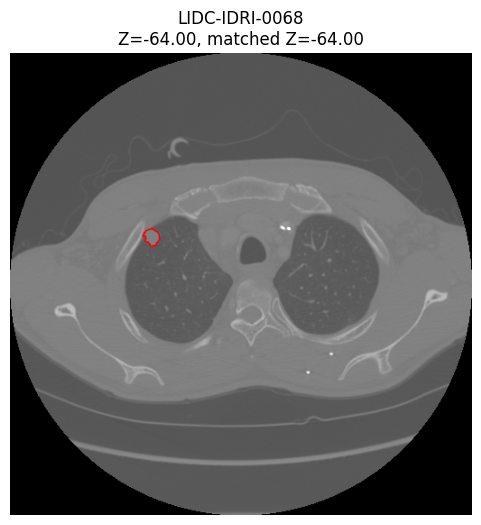

In [22]:
import os
import matplotlib.pyplot as plt
import pydicom
import numpy as np
import pandas as pd

# Load ROI DataFrame
row = df_good.iloc[3]

# Extract data
patient_id = row["PatientID"]
z_target = row["Z"]
# Extract and convert coordinate strings
x_coords = ast.literal_eval(row["X_coords"])
y_coords = ast.literal_eval(row["Y_coords"])


# Load DICOMs
dicom_root = "data/Extension/DICOM_DATA_120_PATIENTS/manifest-1747667983531/LIDC-IDRI"
dicom_patient_dir = os.path.join(dicom_root, patient_id)

dicom_files = []
for root, _, files in os.walk(dicom_patient_dir):
    for f in files:
        if f.endswith(".dcm"):
            dicom_files.append(os.path.join(root, f))

# Match slice by Z
slices = []
for path in dicom_files:
    dcm = pydicom.dcmread(path, stop_before_pixels=True)
    if hasattr(dcm, "SliceLocation"):
        slices.append((abs(dcm.SliceLocation - z_target), path))

if not slices:
    raise ValueError("❌ No matching DICOM slice found.")

# Load and display the best match
closest_path = sorted(slices, key=lambda x: x[0])[0][1]
dcm = pydicom.dcmread(closest_path)

plt.figure(figsize=(6, 6))
plt.imshow(dcm.pixel_array, cmap="gray")
plt.plot(x_coords, y_coords, color="red", linewidth=1)
plt.title(f"{patient_id}\nZ={z_target:.2f}, matched Z={dcm.SliceLocation:.2f}")
plt.axis("off")
plt.show()


### Radiomic Feature Extraction - PyRadiomics

In [4]:
# ✅ Setup PyRadiomics
extractor = featureextractor.RadiomicsFeatureExtractor()
extractor.enableAllFeatures()
extractor.enableImageTypes(Original={}, LoG={}, Wavelet={})


In [7]:
print(f"\n🔍 Patient {patient_id}")
print(f"Z requested: {z_val}")
print(f"Available Zs: {slice_z_positions[126]}")



🔍 Patient LIDC-IDRI-0068


NameError: name 'z_val' is not defined

In [8]:
print(f"\n🛠️ Debug: Patient {patient_id}")
print(f"  Origin:  {origin}")
print(f"  Spacing: {spacing}")
print(f"  Num Z slices: {image3D.GetSize()[2]}")



🛠️ Debug: Patient LIDC-IDRI-0068


NameError: name 'origin' is not defined

In [ ]:
import os
import numpy as np
import pandas as pd
import SimpleITK as sitk
import pydicom
from skimage.draw import polygon
from radiomics import featureextractor
import ast

# ✅ Configure PyRadiomics extractor
extractor = featureextractor.RadiomicsFeatureExtractor()
extractor.enableAllFeatures()
extractor.enableImageTypes(Original={}, LoG={}, Wavelet={})

# ✅ DICOM root path
base_dicom_dir = "data/Extension/DICOM_DATA_120_PATIENTS/manifest-1747667983531/LIDC-IDRI"

# ✅ Helper to find best matching DICOM slice
def find_matching_dcm(patient_id, z_target):
    patient_path = os.path.join(base_dicom_dir, patient_id)
    best_match = None
    best_diff = float("inf")

    for root, _, files in os.walk(patient_path):
        for f in files:
            if f.lower().endswith(".dcm"):
                path = os.path.join(root, f)
                try:
                    dcm = pydicom.dcmread(path, stop_before_pixels=True)
                    if hasattr(dcm, "SliceLocation"):
                        diff = abs(dcm.SliceLocation - z_target)
                        if diff < best_diff:
                            best_diff = diff
                            best_match = path
                except:
                    continue
    return best_match, best_diff

# ✅ Main loop
results = []

for idx, row in df_good.iterrows():
    patient_id = row["PatientID"]
    z_val = row["Z"]
    label = row["Label"]

    # Parse X/Y coords
    x_coords = row["X_coords"]
    y_coords = row["Y_coords"]
    if isinstance(x_coords, str): x_coords = ast.literal_eval(x_coords)
    if isinstance(y_coords, str): y_coords = ast.literal_eval(y_coords)

    try:
        # --- Locate DICOM slice with matching Z ---
        dcm_path, z_diff = find_matching_dcm(patient_id, z_val)
        if dcm_path is None or z_diff > 1.5:
            print(f"⚠️ Skipping {patient_id}: no close enough slice for Z={z_val}")
            continue

        print(f"✅ Using {dcm_path} for {patient_id} Z={z_val} (diff={z_diff:.2f})")

        # --- Load 2D slice as SimpleITK image ---
        slice_image = sitk.ReadImage(dcm_path)

        # ✅ If loaded as (H, W, 1), extract to pure 2D
        if slice_image.GetDimension() == 3 and slice_image.GetSize()[2] == 1:
            slice_image = sitk.Extract(slice_image,
                                        size=[slice_image.GetWidth(), slice_image.GetHeight(), 0],
                                        index=[0, 0, 0])

        # --- Create binary mask ---
        mask_array = np.zeros((slice_image.GetHeight(), slice_image.GetWidth()), dtype=np.uint8)
        rr, cc = polygon(y_coords, x_coords, shape=mask_array.shape)
        mask_array[rr, cc] = 1

        mask = sitk.GetImageFromArray(mask_array, isVector=False)
        mask = sitk.Cast(mask, sitk.sitkUInt8)

        # ✅ Safely assign metadata
        mask.SetSpacing(slice_image.GetSpacing())
        mask.SetOrigin(slice_image.GetOrigin())
        full_direction = slice_image.GetDirection()

        if slice_image.GetDimension() == 3:
            # Extract 2D portion of 3D direction matrix
            direction_2d = (full_direction[0], full_direction[1],
                            full_direction[3], full_direction[4])
        else:
            direction_2d = full_direction  # Already 2D

        mask.SetDirection(direction_2d)


        # --- Extract radiomic features ---
        features = extractor.execute(slice_image, mask)
        features["PatientID"] = patient_id
        features["Z"] = z_val
        features["Label"] = label
        results.append(features)

    except Exception as e:
        print(f"❌ Error on {patient_id} Z={z_val}: {e}")

# ✅ Save extracted features
df_features = pd.DataFrame(results)
df_features.to_csv("RadiomicFeatures.csv", index=False)
print("✅ Radiomic feature extraction complete.")


In [ ]:
df_features.to_csv("data/Extension/RadiomicFeatures.csv", index=False)

In [4]:
df_features = pd.read_csv("data/Extension/RadiomicFeatures.csv")

In [5]:
for col in df_features.columns:
    if df_features[col].apply(lambda x: isinstance(x, np.ndarray)).any():
        df_features[col] = df_features[col].apply(lambda x: x.item() if isinstance(x, np.ndarray) and x.size == 1 else x)

In [6]:
df_features.info()
df_features.isnull().sum()
df_features['Label'].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3239 entries, 0 to 3238
Columns: 499 entries, diagnostics_Versions_PyRadiomics to Label
dtypes: float64(478), int64(3), object(18)
memory usage: 12.3+ MB


Label
1    2834
0     405
Name: count, dtype: int64

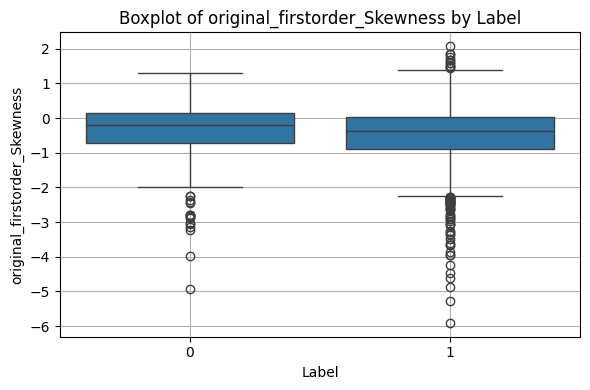

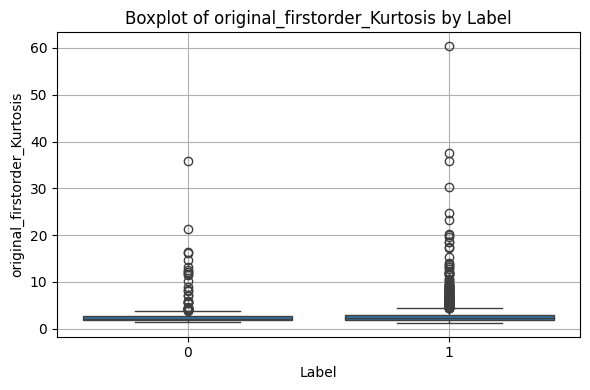

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

features_to_plot = [
    "original_firstorder_Skewness",
    "original_firstorder_Kurtosis"
]

for feature in features_to_plot:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x="Label", y=feature, data=df_features)
    plt.title(f"Boxplot of {feature} by Label")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [7]:
df_features

,diagnostics_Versions_PyRadiomics,diagnostics_Versions_Numpy,diagnostics_Versions_SimpleITK,diagnostics_Versions_PyWavelet,diagnostics_Versions_Python,diagnostics_Configuration_Settings,diagnostics_Configuration_EnabledImageTypes,diagnostics_Image-original_Hash,diagnostics_Image-original_Dimensionality,diagnostics_Image-original_Spacing,...,wavelet-LL_glszm_ZonePercentage,wavelet-LL_glszm_ZoneVariance,wavelet-LL_ngtdm_Busyness,wavelet-LL_ngtdm_Coarseness,wavelet-LL_ngtdm_Complexity,wavelet-LL_ngtdm_Contrast,wavelet-LL_ngtdm_Strength,PatientID,Z,Label
0,3.1.1.dev110+g9b1e030,2.0.2,2.5.0,1.6.0,3.9.6,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'LoG': {}, 'Wavelet': {}}",b118e280833e55e3d48b3540583c185e2e52f424,2D,"(0.683594, 0.683594)",...,0.776119,0.551405,0.004516,0.082137,4661.900634,1.166262,191.017523,LIDC-IDRI-0068,-60.25,1
1,3.1.1.dev110+g9b1e030,2.0.2,2.5.0,1.6.0,3.9.6,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'LoG': {}, 'Wavelet': {}}",6a1d0a510ae7e564d033facc74262b3afa855fd0,2D,"(0.683594, 0.683594)",...,0.591623,6.638578,0.005448,0.045897,5167.514487,0.834860,127.771170,LIDC-IDRI-0068,-61.50,1
2,3.1.1.dev110+g9b1e030,2.0.2,2.5.0,1.6.0,3.9.6,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'LoG': {}, 'Wavelet': {}}",8a3b410a3552c8d49dc8795a682b61c941836d05,2D,"(0.683594, 0.683594)",...,0.559671,6.300119,0.005945,0.034091,7318.441734,0.913141,140.489285,LIDC-IDRI-0068,-62.75,1
3,3.1.1.dev110+g9b1e030,2.0.2,2.5.0,1.6.0,3.9.6,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'LoG': {}, 'Wavelet': {}}",7d7c642c76aac8e3bd418cf7440738eeaf5ab2a1,2D,"(0.683594, 0.683594)",...,0.583643,10.115299,0.006950,0.027648,7833.406940,0.783518,121.534440,LIDC-IDRI-0068,-64.00,1
4,3.1.1.dev110+g9b1e030,2.0.2,2.5.0,1.6.0,3.9.6,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'LoG': {}, 'Wavelet': {}}",e71243a8b7da8a1f76f303ef6eadf121ed685ab0,2D,"(0.683594, 0.683594)",...,0.636735,4.732207,0.007572,0.028659,7991.503464,1.146957,100.719540,LIDC-IDRI-0068,-65.25,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3234,3.1.1.dev110+g9b1e030,2.0.2,2.5.0,1.6.0,3.9.6,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'LoG': {}, 'Wavelet': {}}",68e1ff3c3cc58272838f281ea3f17193e9b0b47d,2D,"(0.898438, 0.898438)",...,0.456098,30.877377,0.007250,0.011772,16074.545007,0.413772,152.944105,LIDC-IDRI-0289,-139.00,0
3235,3.1.1.dev110+g9b1e030,2.0.2,2.5.0,1.6.0,3.9.6,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'LoG': {}, 'Wavelet': {}}",0a48a075cba78d869f6d3d7fe04f44516e8f3081,2D,"(0.898438, 0.898438)",...,0.425393,39.569269,0.007275,0.013363,10202.605600,0.217997,116.296660,LIDC-IDRI-0289,-141.50,0
3236,3.1.1.dev110+g9b1e030,2.0.2,2.5.0,1.6.0,3.9.6,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'LoG': {}, 'Wavelet': {}}",3403920f96c33869e2c023e73396b62509cc1b1f,2D,"(0.898438, 0.898438)",...,0.367442,36.665064,0.008893,0.014147,5861.433941,0.297837,118.462615,LIDC-IDRI-0289,-144.00,0
3237,3.1.1.dev110+g9b1e030,2.0.2,2.5.0,1.6.0,3.9.6,"{'minimumROIDimensions': 2, 'minimumROISize': ...","{'Original': {}, 'LoG': {}, 'Wavelet': {}}",4c1ea10c81b237fff920c39dd558520337a5019b,2D,"(0.898438, 0.898438)",...,0.581911,7.410480,0.003137,0.049858,4441.027566,0.254437,179.368916,LIDC-IDRI-0289,-146.50,0


In [8]:
# Columns to keep
cols_to_keep = ["Label", "PatientID", "Z"]  # or adjust as needed

# Filter all 'original_' features
original_cols = [col for col in df_features.columns if col.startswith("original")]

# Final filtered DataFrame
df_original_only = df_features[cols_to_keep + original_cols]

,Label,PatientID,Z,original_shape2D_Elongation,original_shape2D_MajorAxisLength,original_shape2D_MaximumDiameter,original_shape2D_MeshSurface,original_shape2D_MinorAxisLength,original_shape2D_Perimeter,original_shape2D_PerimeterSurfaceRatio,...,original_glszm_SmallAreaHighGrayLevelEmphasis,original_glszm_SmallAreaLowGrayLevelEmphasis,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength
0,1,LIDC-IDRI-0068,-60.25,0.610483,12.019090,12.323666,62.384651,7.337448,34.774466,0.557420,...,371.942204,0.032759,5.401319,0.597015,4.844375,0.012440,0.081149,937.126296,0.404362,59.862369
1,1,LIDC-IDRI-0068,-61.50,0.853944,11.854907,13.272995,89.020794,10.123424,41.375834,0.464788,...,503.249295,0.017044,5.162615,0.502618,26.760308,0.017132,0.040886,1110.032937,0.286762,40.727742
2,1,LIDC-IDRI-0068,-62.75,0.836806,13.257974,13.824833,113.320434,11.094350,41.942142,0.370120,...,404.328598,0.021363,5.410592,0.440329,26.889161,0.020663,0.030645,1414.520474,0.400539,39.334654
3,1,LIDC-IDRI-0068,-64.00,0.854548,13.842394,14.371741,125.470253,11.828990,47.176321,0.375996,...,528.875506,0.017765,5.442984,0.460967,22.511642,0.023051,0.026498,1468.361265,0.336729,35.894374
4,1,LIDC-IDRI-0068,-65.25,0.914994,12.664651,13.149193,114.255035,11.588079,40.809526,0.357179,...,502.604129,0.012600,5.489514,0.534694,9.028961,0.025975,0.027174,1516.066140,0.489295,28.794116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3234,0,LIDC-IDRI-0289,-139.00,0.691792,35.142574,36.161432,661.492893,24.311346,101.970444,0.154152,...,1003.461228,0.017163,6.175036,0.396341,57.591006,0.029565,0.009203,3887.479017,0.218008,33.797624
3235,0,LIDC-IDRI-0289,-141.50,0.792865,31.826090,31.904038,616.290206,25.233802,98.902985,0.160481,...,1153.472603,0.007131,5.967957,0.405759,27.803580,0.027426,0.009499,3102.741367,0.089469,35.380311
3236,0,LIDC-IDRI-0289,-144.00,0.769889,29.513302,31.290933,520.234496,22.721967,90.008903,0.173016,...,776.371033,0.013384,5.786637,0.350388,105.983104,0.031982,0.011965,1514.606935,0.131020,32.496181
3237,0,LIDC-IDRI-0289,-146.50,0.857120,26.844046,28.665664,472.610237,23.008579,85.670860,0.181272,...,581.414583,0.006795,6.211686,0.525597,9.354149,0.017992,0.031693,1005.290170,0.169636,35.249453


In [12]:
df_original_only["Label"].value_counts()

Label
1    2834
0     405
Name: count, dtype: int64

In [13]:
# Drop all shape2D features
shape_cols = [col for col in df_original_only.columns if "shape2D" in col]
df_original_noshape = df_original_only.drop(columns=shape_cols)

print(f"✅ Dropped {len(shape_cols)} shape2D features. New shape: {df_original_noshape.shape}")


✅ Dropped 9 shape2D features. New shape: (3239, 96)


In [14]:
df_original_noshape

,Label,PatientID,Z,original_firstorder_10Percentile,original_firstorder_90Percentile,original_firstorder_Energy,original_firstorder_Entropy,original_firstorder_InterquartileRange,original_firstorder_Kurtosis,original_firstorder_Maximum,...,original_glszm_SmallAreaHighGrayLevelEmphasis,original_glszm_SmallAreaLowGrayLevelEmphasis,original_glszm_ZoneEntropy,original_glszm_ZonePercentage,original_glszm_ZoneVariance,original_ngtdm_Busyness,original_ngtdm_Coarseness,original_ngtdm_Complexity,original_ngtdm_Contrast,original_ngtdm_Strength
0,1,LIDC-IDRI-0068,-60.25,-662.2,26.0,16997676.0,4.474829,457.00,1.992209,48.0,...,371.942204,0.032759,5.401319,0.597015,4.844375,0.012440,0.081149,937.126296,0.404362,59.862369
1,1,LIDC-IDRI-0068,-61.50,-482.0,38.0,11192364.0,3.851390,193.50,4.115603,75.0,...,503.249295,0.017044,5.162615,0.502618,26.760308,0.017132,0.040886,1110.032937,0.286762,40.727742
2,1,LIDC-IDRI-0068,-62.75,-589.0,43.0,19537994.0,3.885587,262.50,3.724402,66.0,...,404.328598,0.021363,5.410592,0.440329,26.889161,0.020663,0.030645,1414.520474,0.400539,39.334654
3,1,LIDC-IDRI-0068,-64.00,-527.2,44.2,18808008.0,3.942343,191.00,4.077576,85.0,...,528.875506,0.017765,5.442984,0.460967,22.511642,0.023051,0.026498,1468.361265,0.336729,35.894374
4,1,LIDC-IDRI-0068,-65.25,-598.0,55.6,20066977.0,4.067720,348.00,3.108010,90.0,...,502.604129,0.012600,5.489514,0.534694,9.028961,0.025975,0.027174,1516.066140,0.489295,28.794116
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3234,0,LIDC-IDRI-0289,-139.00,-711.0,95.1,82090312.0,3.847449,56.25,5.634014,733.0,...,1003.461228,0.017163,6.175036,0.396341,57.591006,0.029565,0.009203,3887.479017,0.218008,33.797624
3235,0,LIDC-IDRI-0289,-141.50,-71.3,94.4,31428816.0,3.538657,53.00,12.183101,605.0,...,1153.472603,0.007131,5.967957,0.405759,27.803580,0.027426,0.009499,3102.741367,0.089469,35.380311
3236,0,LIDC-IDRI-0289,-144.00,-276.0,62.0,29207168.0,3.349594,52.00,10.151441,133.0,...,776.371033,0.013384,5.786637,0.350388,105.983104,0.031982,0.011965,1514.606935,0.131020,32.496181
3237,0,LIDC-IDRI-0289,-146.50,-642.5,22.0,59903723.0,4.610448,307.00,3.413919,73.0,...,581.414583,0.006795,6.211686,0.525597,9.354149,0.017992,0.031693,1005.290170,0.169636,35.249453


### KW FDR + Correlation

In [16]:
from scipy.stats import kruskal
from statsmodels.stats.multitest import multipletests
import pandas as pd

# 1. Prepare data
X = df_original_noshape.drop(columns=["Label", "PatientID", "Z"])
y = df_original_noshape["Label"]

# 2. Perform Kruskal-Wallis test
p_values = [kruskal(X[col][y == 0], X[col][y == 1]).pvalue for col in X.columns]

# 3. FDR correction
fdr_pass, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method="fdr_bh")

# 4. Get selected features
selected_features = X.columns[fdr_pass]
X_selected = X[selected_features]

print(f"✅ Selected {len(selected_features)} features out of {X.shape[1]} after FDR correction.")


✅ Selected 54 features out of 93 after FDR correction.


In [41]:
import pingouin as pg

# Add subject column for rm_corr (e.g. PatientID)
df_corr = df_original_noshape[["PatientID"] + list(X_selected.columns)].copy()

# Compute scores from Kruskal-Wallis (already done)
scores = {feature: 1 - p for feature, p in zip(X_selected.columns, pvals_corrected) if feature in X_selected.columns}

selected_features = list(X_selected.columns)
dropped_features = set()

for i, key1 in enumerate(selected_features):
    for key2 in selected_features[i + 1:]:
        if key1 in dropped_features or key2 in dropped_features:
            continue

        try:
            result = pg.rm_corr(data=df_corr, x=key1, y=key2, subject="PatientID")
            r = result["r"].values[0]

            if r > 0.9:
                score1 = scores.get(key1, 0)
                score2 = scores.get(key2, 0)

                if score2 > score1:
                    dropped_features.add(key1)
                elif score1 > score2:
                    dropped_features.add(key2)
                else:
                    dropped_features.add(key2)

        except Exception as e:
            print(f"⚠️ Failed correlation between {key1} and {key2}: {e}")

# Final set of decorrelated features
final_features = list(set(selected_features) - dropped_features)
print(f"✅ {len(final_features)} features selected after rm_corr filtering")

# Optional: reduced feature matrix
X_filtered = df_original_noshape[final_features]


✅ 38 features selected after rm_corr filtering


### ML Models

In [42]:
from sklearn.model_selection import train_test_split

X = df_original_noshape[final_features]
y = df_original_noshape["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("clf", RandomForestClassifier(class_weight="balanced", random_state=42))
])


In [44]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(pipeline, X_train, y_train, cv=cv, scoring="roc_auc")
print("Cross-validated AUCs:", scores)
print("Mean AUC:", scores.mean())


Cross-validated AUCs: [0.84857675 0.88876652 0.83324843 0.89032094 0.87432501]
Mean AUC: 0.867047530563591


In [45]:
from sklearn.metrics import classification_report, roc_auc_score

pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

print("Test AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred, digits=3))


Test AUC: 0.8713937335336512
              precision    recall  f1-score   support

           0      0.882     0.185     0.306        81
           1      0.895     0.996     0.943       567

    accuracy                          0.895       648
   macro avg      0.889     0.591     0.625       648
weighted avg      0.894     0.895     0.864       648



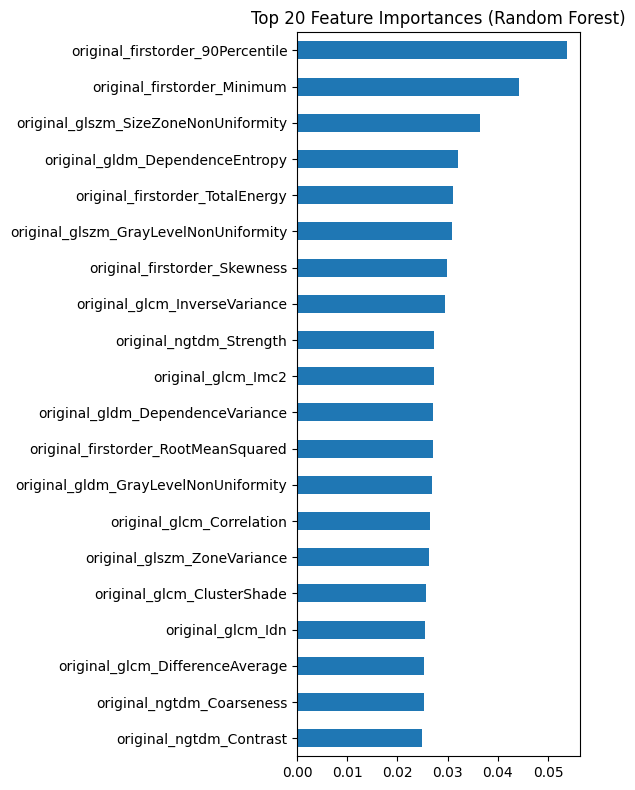

In [29]:
import matplotlib.pyplot as plt
import pandas as pd

importances = pipeline.named_steps["clf"].feature_importances_
feat_imp = pd.Series(importances, index=final_features)
feat_imp.nlargest(20).sort_values().plot(kind="barh", figsize=(6, 8))
plt.title("Top 20 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()


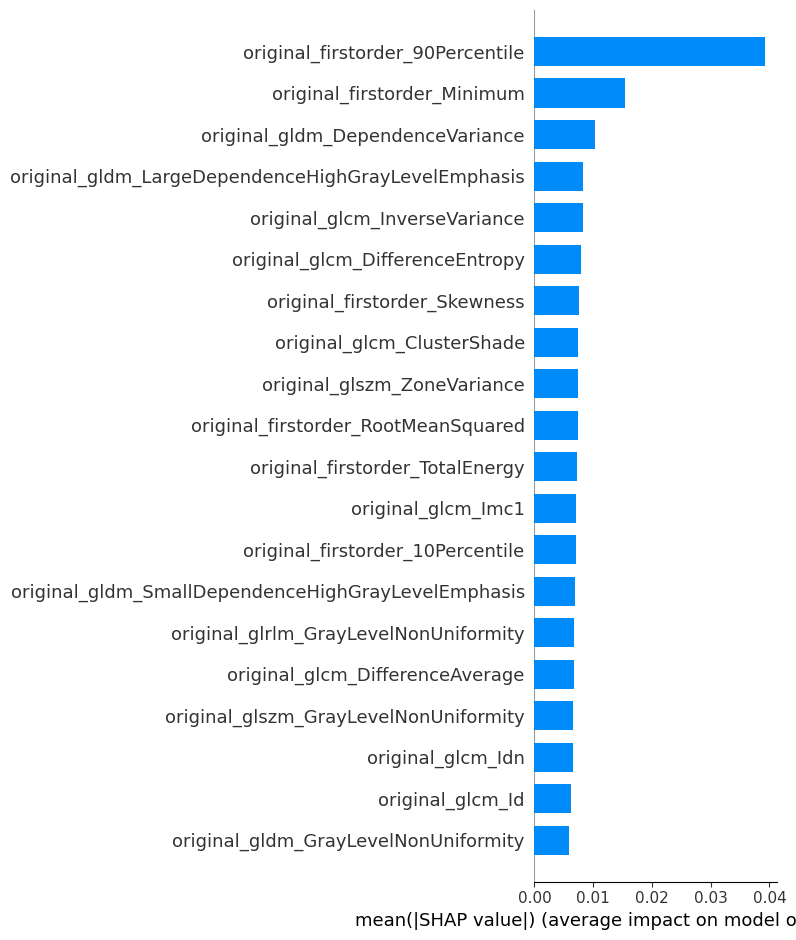

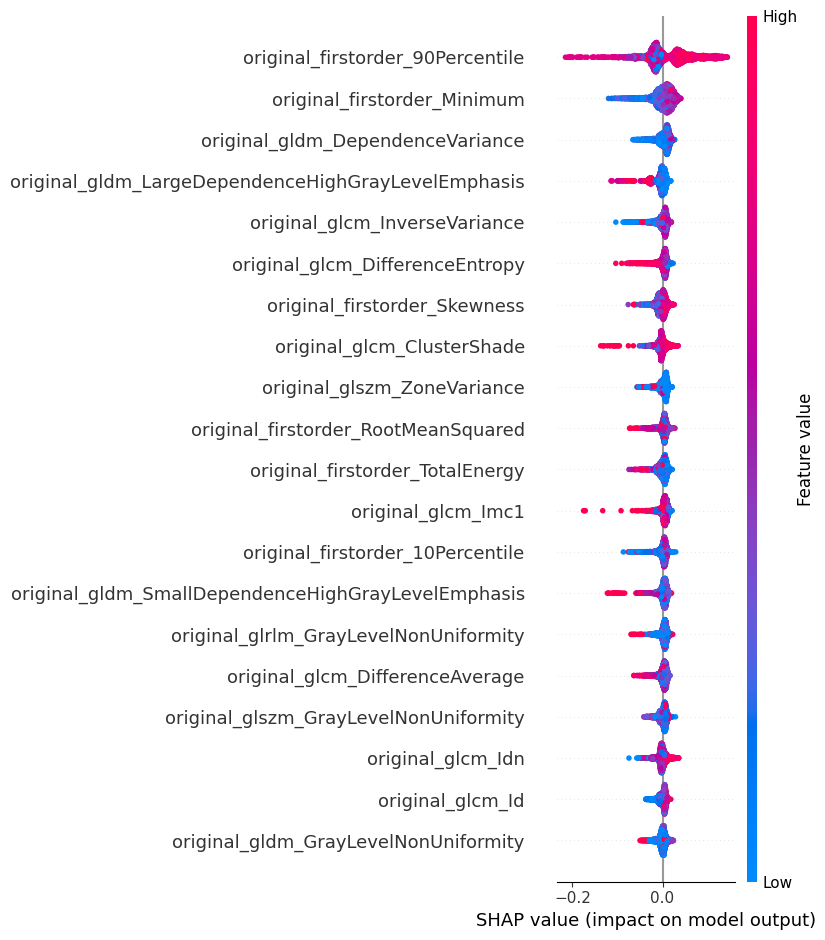

In [31]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import shap

# Encode target labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # 0 and 1

# Fit Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X, y_encoded)

# SHAP explainer
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)  # shape: (n_samples, n_features, n_classes)

# Extract class 1 SHAP values
shap_values_class1 = shap_values[:, :, 1]  # shape: (n_samples, n_features)

# Plot
shap.summary_plot(shap_values_class1, X, feature_names=X.columns, plot_type="bar")
shap.summary_plot(shap_values_class1, X, feature_names=X.columns)


### SMOTE Apprach


In [46]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Re-split if needed
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# Apply SMOTE only to training set
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("✅ After SMOTE:", pd.Series(y_train_resampled).value_counts())


✅ After SMOTE: Label
1    2267
0    2267
Name: count, dtype: int64


/Users/saamnazem/mphil_project/sn665/venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


In [47]:
# Train
pipeline.fit(X_train_resampled, y_train_resampled)

# Evaluate on real test data
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

# Metrics
from sklearn.metrics import classification_report, roc_auc_score

print("Test AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred, digits=3))


Test AUC: 0.8548457334465566
              precision    recall  f1-score   support

           0      0.432     0.506     0.466        81
           1      0.928     0.905     0.916       567

    accuracy                          0.855       648
   macro avg      0.680     0.705     0.691       648
weighted avg      0.866     0.855     0.860       648



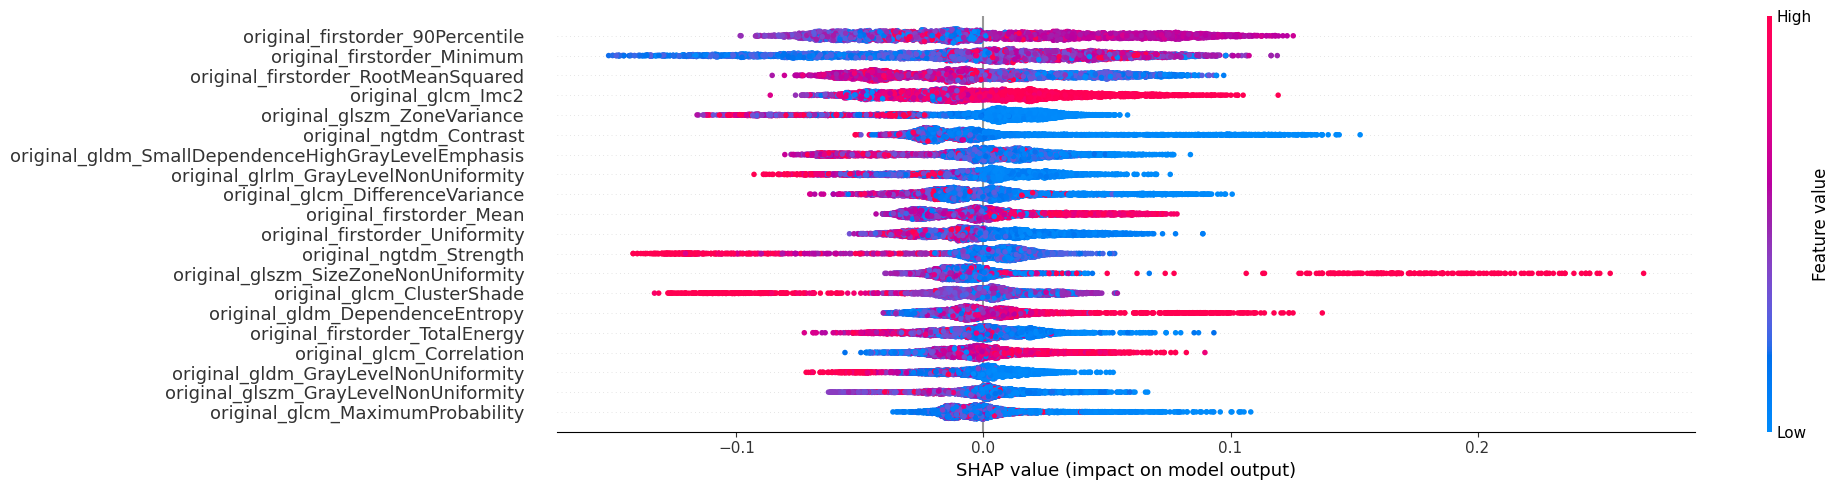

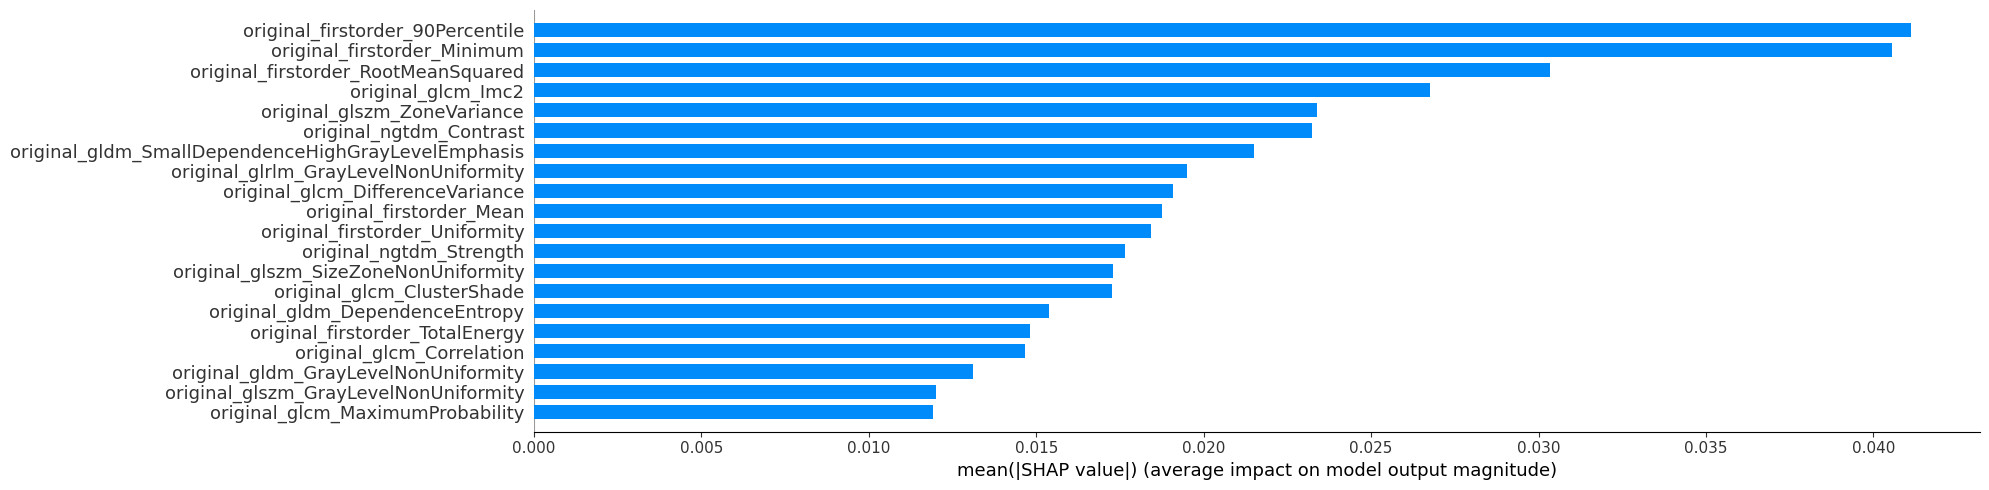

In [56]:
# Fit on resampled training set
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train_resampled, y_train_resampled)

# SHAP explainer
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_train_resampled)

# Class 1 SHAP values
shap_values_class1 = shap_values[:, :, 1]

# Plot

shap.summary_plot(
    shap_values_class1,
    X_train_resampled,          # ✅ must match what SHAP saw
    feature_names=X.columns,   # optionally: X_train_resampled.columns
    plot_size=(20, 5)
)

shap.summary_plot(
    shap_values_class1,
    X_train_resampled,         # ✅ again here
    feature_names=X.columns,
    plot_size=(20, 5),
    plot_type="bar"
)




In [55]:
print("X shape:", X.shape)
print("SHAP values shape:", shap_values_class1.shape)


X shape: (3239, 38)
SHAP values shape: (4534, 38)
